In [1]:
import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# 0) File path (update if needed)
# -------------------------------------------------------------------
CSV_PATH = "NTAD_National_Bridge_Inventory_-6282134062105639862.csv"

# -------------------------------------------------------------------
# 1) Choose "necessary" columns for preliminary design modelling
#    (IDs are kept only for traceability; you can drop later)
# -------------------------------------------------------------------
USECOLS = [
    # IDs / context
    "STATE_CODE_001",
    "STRUCTURE_NUMBER_008",
    "FUNCTIONAL_CLASS_026",

    # Geometry / scheme (core preliminary design predictors)
    "STRUCTURE_LEN_MT_049",     # total length (m)
    "MAX_SPAN_LEN_MT_048",      # max span (m)
    "MAIN_UNIT_SPANS_045",      # number of spans
    "DECK_WIDTH_MT_052",        # deck width (m)
    "APPR_WIDTH_MT_032",        # approach roadway width (m)
    "DEGREES_SKEW_034",         # skew (deg)

    # Traffic / demand proxies
    "ADT_029",
    "PERCENT_ADT_TRUCK_109",
    "TRAFFIC_LANES_ON_028A",

    # Age proxy (often strongly related to form choices, standards, etc.)
    "YEAR_BUILT_027",

    # Structure type coding (targets for Stage 1)
    "STRUCTURE_KIND_043A",
    "STRUCTURE_TYPE_043B",
]

# -------------------------------------------------------------------
# 2) Load only these columns (saves RAM/time)
# -------------------------------------------------------------------
df = pd.read_csv(
    CSV_PATH,
    usecols=USECOLS,
    low_memory=False
)

# -------------------------------------------------------------------
# 3) Basic cleaning: numeric coercion + standard missing handling
# -------------------------------------------------------------------
NUM_COLS = [
    "STRUCTURE_LEN_MT_049", "MAX_SPAN_LEN_MT_048", "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052", "APPR_WIDTH_MT_032", "DEGREES_SKEW_034",
    "ADT_029", "PERCENT_ADT_TRUCK_109", "TRAFFIC_LANES_ON_028A",
    "YEAR_BUILT_027", "STRUCTURE_KIND_043A", "STRUCTURE_TYPE_043B",
    "FUNCTIONAL_CLASS_026",
]

for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows missing the essential scheme variables
df = df.dropna(subset=[
    "STRUCTURE_LEN_MT_049",
    "MAX_SPAN_LEN_MT_048",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "ADT_029",
    "STRUCTURE_TYPE_043B"
])

# Remove obviously invalid / placeholder values (optional but sensible)
df = df[
    (df["STRUCTURE_LEN_MT_049"] > 0) &
    (df["MAX_SPAN_LEN_MT_048"] > 0) &
    (df["MAIN_UNIT_SPANS_045"] > 0) &
    (df["DECK_WIDTH_MT_052"] > 0) &
    (df["ADT_029"] >= 0)
].copy()

# -------------------------------------------------------------------
# 4) Stage 1 target: map NBI "STRUCTURE_TYPE_043B" to form family
#    NOTE: This is a *practical* grouping for preliminary design.
#    You can refine it later using mtguide definitions if you want.
# -------------------------------------------------------------------
def map_form_family(structure_type_43b: float) -> str:
    """
    Maps NBI item 43B (type of design/construction) into a small set of
    preliminary-design form families.

    Returns: 'girder_beam', 'truss', 'arch', 'rigid_frame', or 'other'
    """
    if pd.isna(structure_type_43b):
        return "other"
    t = int(structure_type_43b)

    # Truss (deck or through)
    if t in (9, 10):
        return "truss"

    # Arch (deck or through)
    if t in (11, 12):
        return "arch"

    # Frame (rigid frame)
    if t == 7:
        return "rigid_frame"

    # Beam/girder family (includes slab + girder-ish families)
    # (You can tighten/expand this list after checking mtguide.)
    if t in (1, 2, 3, 4, 5, 6, 16, 17, 18, 20, 21, 22):
        return "girder_beam"

    return "other"

df["FORM_FAMILY"] = df["STRUCTURE_TYPE_043B"].apply(map_form_family)

# Keep only the four core form families for a clean “conceptual selection” study
df_stage1 = df[df["FORM_FAMILY"].isin(["girder_beam", "truss", "arch", "rigid_frame"])].copy()

# -------------------------------------------------------------------
# 5) Stage 2 targets: span scheme (bands) for robust classification
#    (Bands are often more stable than exact values at concept stage.)
# -------------------------------------------------------------------
# Span count band (you can tweak thresholds)
df_stage1["SPAN_COUNT_BAND"] = pd.cut(
    df_stage1["MAIN_UNIT_SPANS_045"],
    bins=[0, 1, 3, 6, np.inf],
    labels=["1", "2-3", "4-6", "7+"],
    right=True
)

# Maximum span band (metres)
df_stage1["MAX_SPAN_BAND_M"] = pd.cut(
    df_stage1["MAX_SPAN_LEN_MT_048"],
    bins=[0, 10, 20, 30, 50, np.inf],
    labels=["<10", "10-20", "20-30", "30-50", "50+"],
    right=True
)

# Optionally: drop rows where bands are NaN (should be rare after cleaning)
df_stage1 = df_stage1.dropna(subset=["SPAN_COUNT_BAND", "MAX_SPAN_BAND_M"])

# -------------------------------------------------------------------
# 6) Final feature set (X) – keep it “preliminary design friendly”
# -------------------------------------------------------------------
FEATURES = [
    "STRUCTURE_LEN_MT_049",
    "MAX_SPAN_LEN_MT_048",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "APPR_WIDTH_MT_032",
    "DEGREES_SKEW_034",
    "ADT_029",
    "PERCENT_ADT_TRUCK_109",
    "TRAFFIC_LANES_ON_028A",
    "YEAR_BUILT_027",
    "FUNCTIONAL_CLASS_026",
]

# Targets
TARGET_FORM = "FORM_FAMILY"
TARGET_SPANCOUNT = "SPAN_COUNT_BAND"
TARGET_MAXSPAN = "MAX_SPAN_BAND_M"

# Keep only modelling-ready columns (+ IDs for traceability)
KEEP = ["STATE_CODE_001", "STRUCTURE_NUMBER_008"] + FEATURES + [TARGET_FORM, TARGET_SPANCOUNT, TARGET_MAXSPAN]
df_model = df_stage1[KEEP].copy()

print("Rows (model-ready):", len(df_model))
print("Form-family distribution:\n", df_model[TARGET_FORM].value_counts(dropna=False))
print("Span-count band distribution:\n", df_model[TARGET_SPANCOUNT].value_counts(dropna=False))
print("Max-span band distribution:\n", df_model[TARGET_MAXSPAN].value_counts(dropna=False))

# -------------------------------------------------------------------
# 7) Save cleaned dataset
# -------------------------------------------------------------------
df_model.to_csv("NBI_preliminary_design_clean.csv", index=False)
# Parquet is faster/smaller if you use it:
# df_model.to_parquet("NBI_preliminary_design_clean.parquet", index=False)


Rows (model-ready): 471799
Form-family distribution:
 FORM_FAMILY
girder_beam    451553
truss            7291
arch             6692
rigid_frame      6263
Name: count, dtype: int64
Span-count band distribution:
 SPAN_COUNT_BAND
1      197357
2-3    185467
4-6     65741
7+      23234
Name: count, dtype: int64
Max-span band distribution:
 MAX_SPAN_BAND_M
10-20    177973
<10      129778
20-30     88923
30-50     63272
50+       11853
Name: count, dtype: int64


Dataset shape: (471799, 16)

Columns:
['STATE_CODE_001', 'STRUCTURE_NUMBER_008', 'STRUCTURE_LEN_MT_049', 'MAX_SPAN_LEN_MT_048', 'MAIN_UNIT_SPANS_045', 'DECK_WIDTH_MT_052', 'APPR_WIDTH_MT_032', 'DEGREES_SKEW_034', 'ADT_029', 'PERCENT_ADT_TRUCK_109', 'TRAFFIC_LANES_ON_028A', 'YEAR_BUILT_027', 'FUNCTIONAL_CLASS_026', 'FORM_FAMILY', 'SPAN_COUNT_BAND', 'MAX_SPAN_BAND_M']

Missing values:
PERCENT_ADT_TRUCK_109    20287
TRAFFIC_LANES_ON_028A        1
STATE_CODE_001               0
STRUCTURE_NUMBER_008         0
STRUCTURE_LEN_MT_049         0
MAX_SPAN_LEN_MT_048          0
MAIN_UNIT_SPANS_045          0
DECK_WIDTH_MT_052            0
APPR_WIDTH_MT_032            0
DEGREES_SKEW_034             0
ADT_029                      0
YEAR_BUILT_027               0
FUNCTIONAL_CLASS_026         0
FORM_FAMILY                  0
SPAN_COUNT_BAND              0
MAX_SPAN_BAND_M              0
dtype: int64

Numerical summary:
                          count         mean           std     min      5%  \
STRUCTU

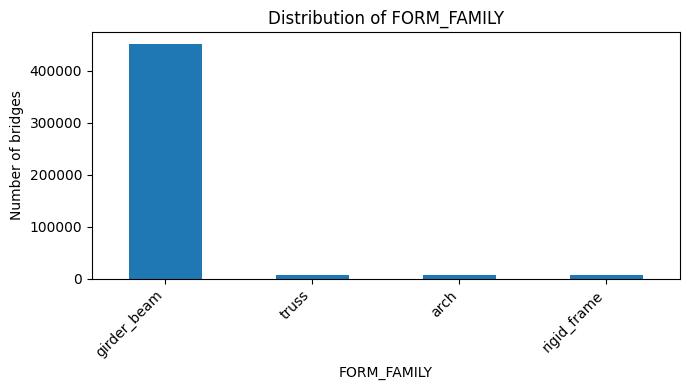


Distribution of SPAN_COUNT_BAND:
                  count  percentage
SPAN_COUNT_BAND                    
1                197357       41.83
2-3              185467       39.31
4-6               65741       13.93
7+                23234        4.92


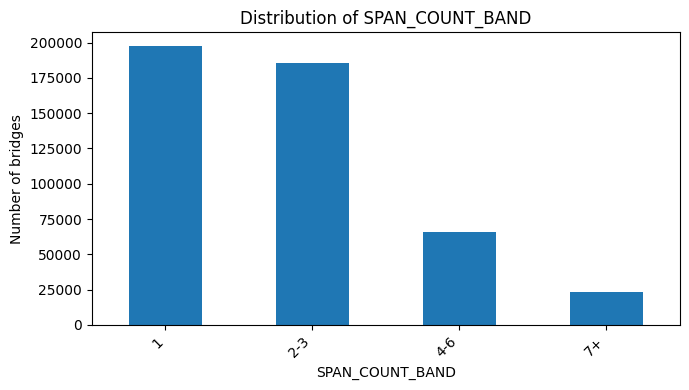


Distribution of MAX_SPAN_BAND_M:
                  count  percentage
MAX_SPAN_BAND_M                    
10-20            177973       37.72
<10              129778       27.51
20-30             88923       18.85
30-50             63272       13.41
50+               11853        2.51


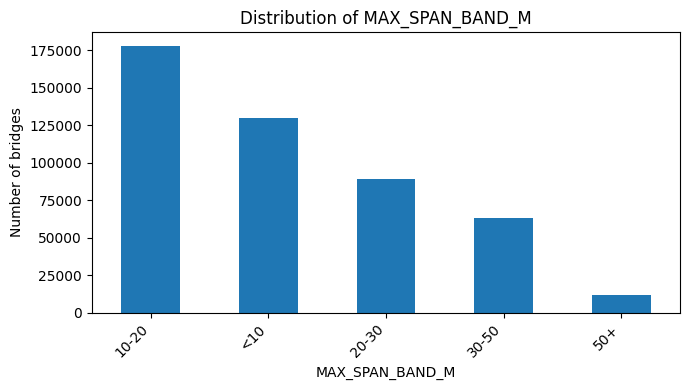

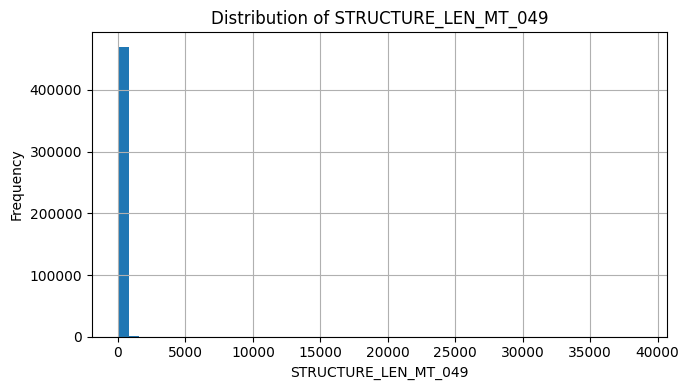

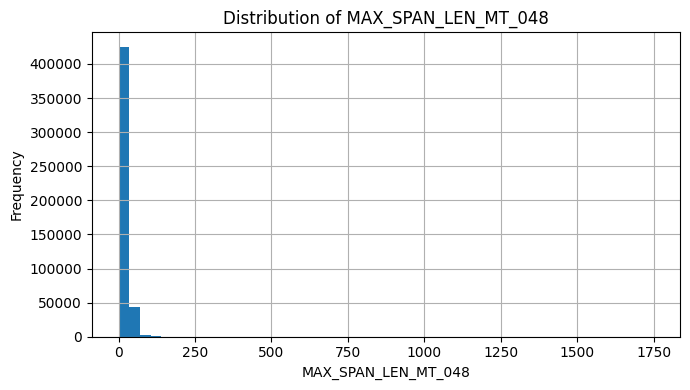

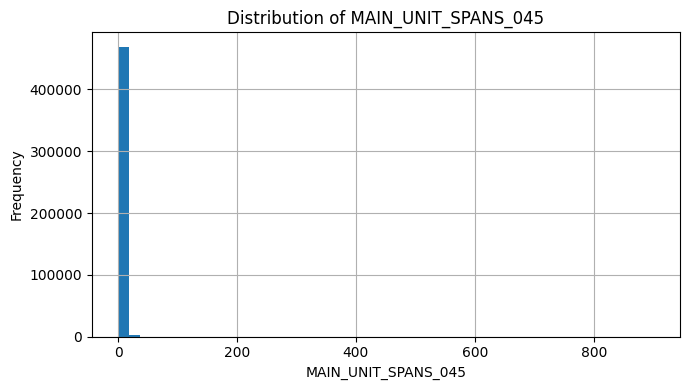

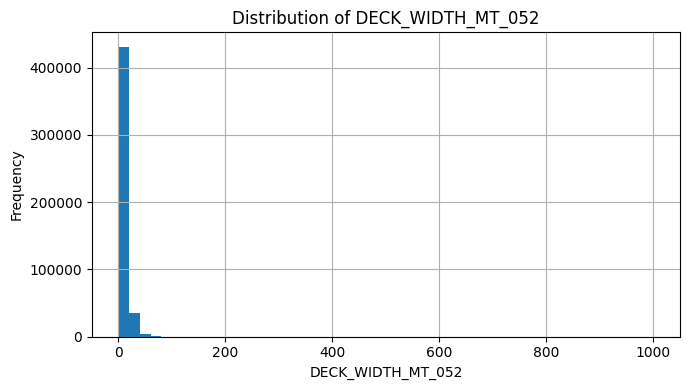

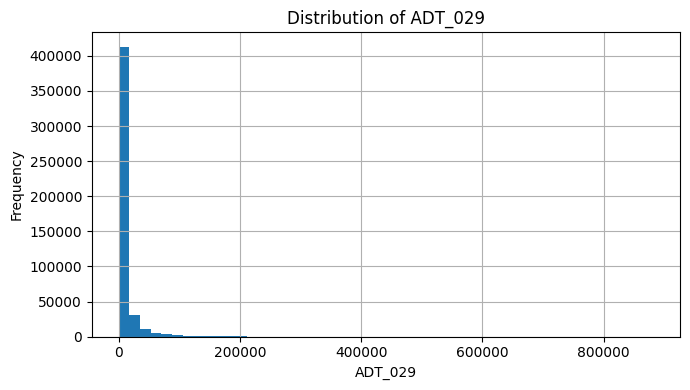

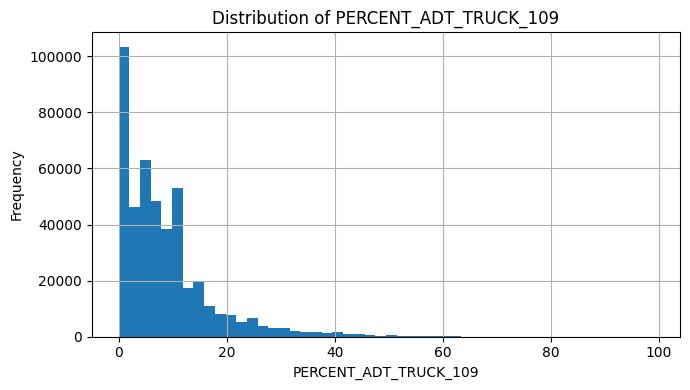

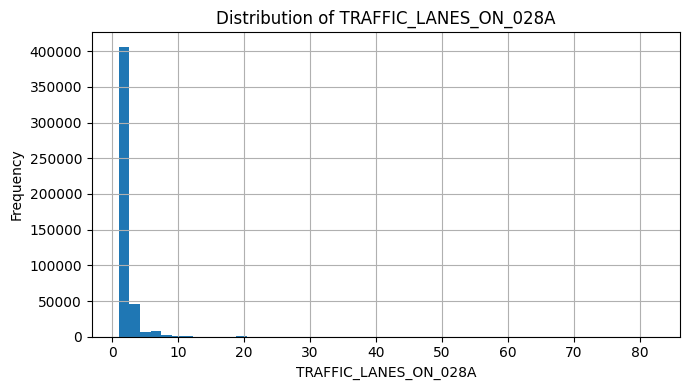

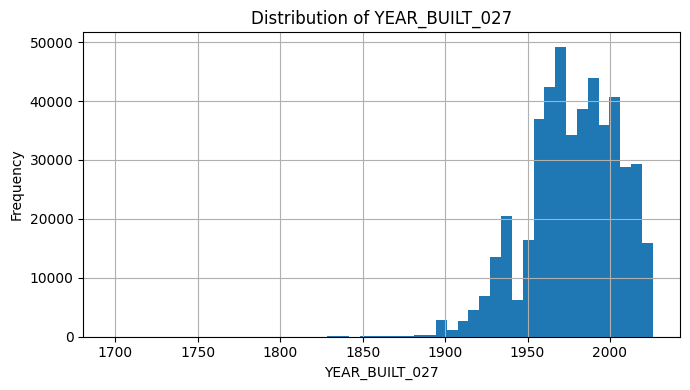

<Figure size 800x400 with 0 Axes>

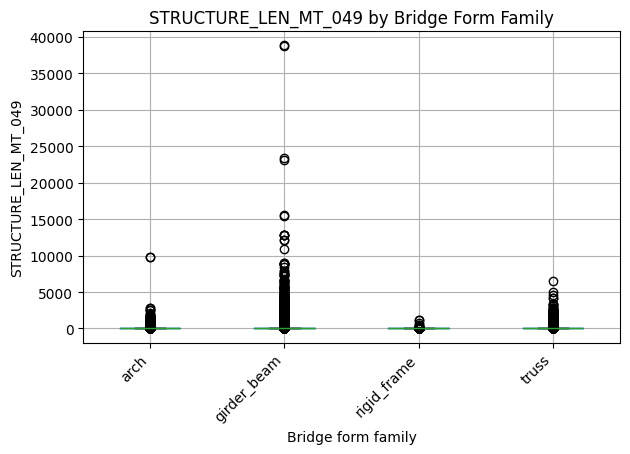

<Figure size 800x400 with 0 Axes>

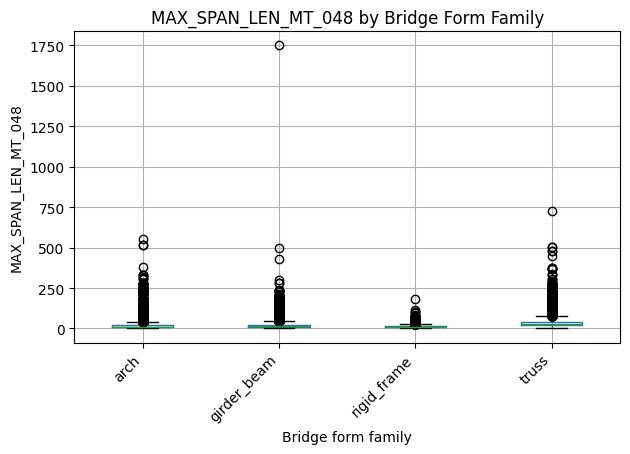

<Figure size 800x400 with 0 Axes>

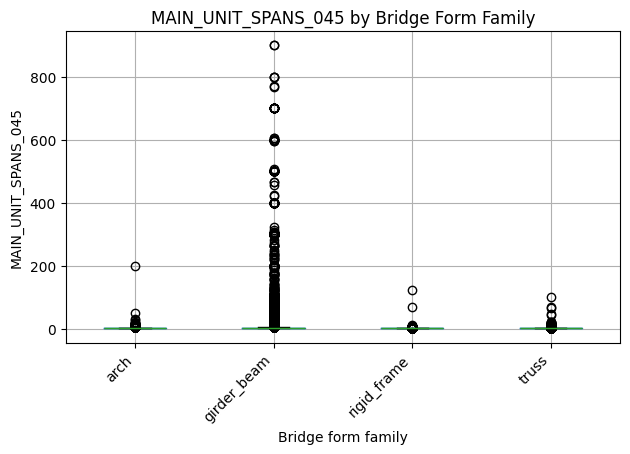

<Figure size 800x400 with 0 Axes>

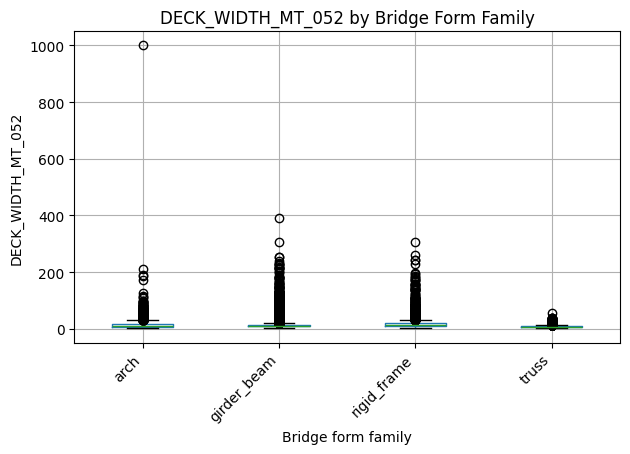

<Figure size 800x400 with 0 Axes>

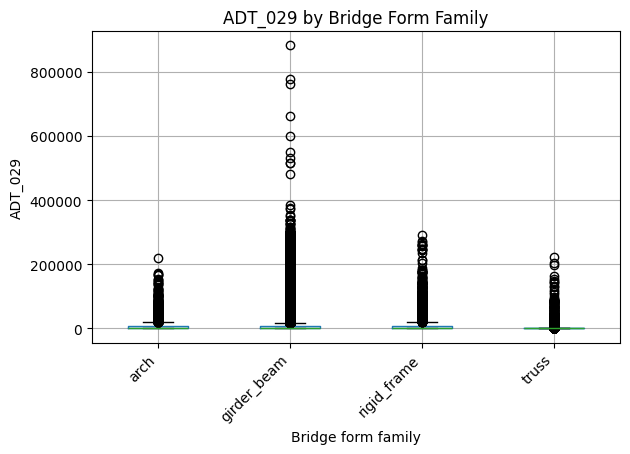


Form family vs span-count band (% within form):
SPAN_COUNT_BAND      1    2-3    4-6    7+
FORM_FAMILY                               
arch             73.98  20.56   3.90  1.55
girder_beam      40.19  40.28  14.43  5.10
rigid_frame      77.98  20.10   1.69  0.22
truss            83.13  12.95   2.74  1.18

Form family vs max-span band (% within form):
MAX_SPAN_BAND_M    <10  10-20  20-30  30-50    50+
FORM_FAMILY                                       
arch             38.64  35.76  12.13   6.99   6.47
girder_beam      27.39  38.00  18.94  13.40   2.27
rigid_frame      54.27  34.15   8.99   2.11   0.48
truss             1.45  25.58  27.72  29.56  15.69

Correlation matrix:
                       STRUCTURE_LEN_MT_049  MAX_SPAN_LEN_MT_048  \
STRUCTURE_LEN_MT_049                   1.00                 0.37   
MAX_SPAN_LEN_MT_048                    0.37                 1.00   
MAIN_UNIT_SPANS_045                    0.28                 0.02   
DECK_WIDTH_MT_052                      0.10    

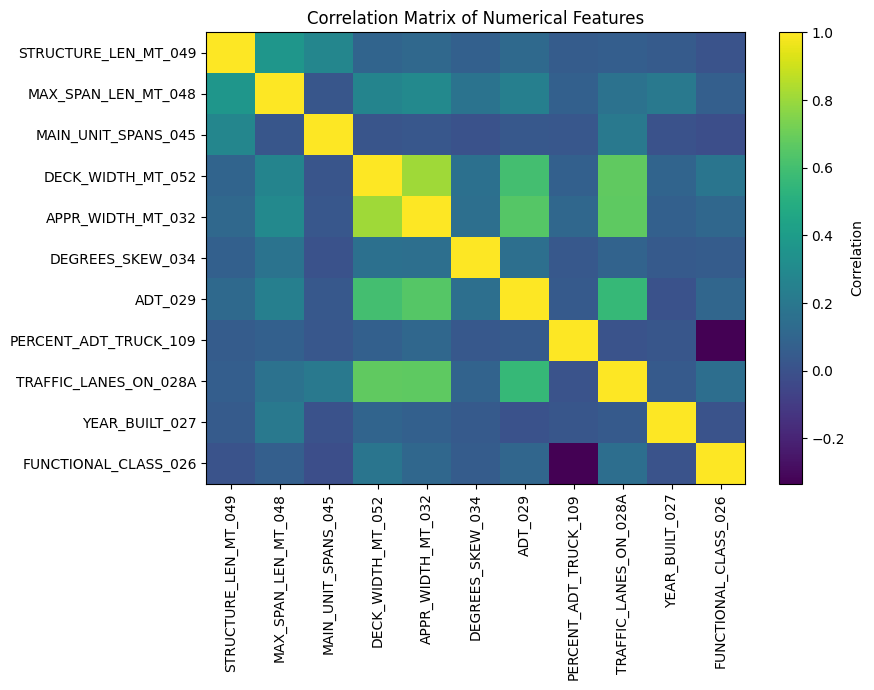


Extreme value summary:
                        0.950     0.990      0.995     1.000
STRUCTURE_LEN_MT_049    154.2     480.1     720.90   38791.6
MAX_SPAN_LEN_MT_048      42.1      64.9      76.20    1748.6
MAIN_UNIT_SPANS_045       6.0      15.0      21.00     900.0
DECK_WIDTH_MT_052        25.6      41.5      48.30     999.9
ADT_029               40644.6  113699.0  155290.65  882085.0


In [2]:
# -------------------------------------------------------------------
# 8) Exploratory Data Analysis
# -------------------------------------------------------------------
import matplotlib.pyplot as plt

# Create output folder
import os
os.makedirs("eda_outputs", exist_ok=True)

# -------------------------------------------------
# 8.1 Basic dataset summary
# -------------------------------------------------
print("Dataset shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

print("\nMissing values:")
print(df_model.isna().sum().sort_values(ascending=False))

print("\nNumerical summary:")
print(df_model[FEATURES].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T)

# Save descriptive statistics
df_model[FEATURES].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T.to_csv(
    "eda_outputs/descriptive_statistics.csv"
)

# -------------------------------------------------
# 8.2 Target distributions
# -------------------------------------------------
target_cols = [TARGET_FORM, TARGET_SPANCOUNT, TARGET_MAXSPAN]

for col in target_cols:
    counts = df_model[col].value_counts(dropna=False)
    perc = df_model[col].value_counts(normalize=True, dropna=False) * 100

    summary = pd.DataFrame({
        "count": counts,
        "percentage": perc.round(2)
    })

    print(f"\nDistribution of {col}:")
    print(summary)

    summary.to_csv(f"eda_outputs/{col}_distribution.csv")

    plt.figure(figsize=(7, 4))
    counts.plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of bridges")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"eda_outputs/{col}_distribution.png", dpi=300)
    plt.show()

# -------------------------------------------------
# 8.3 Numerical feature histograms
# -------------------------------------------------
numeric_features = [
    "STRUCTURE_LEN_MT_049",
    "MAX_SPAN_LEN_MT_048",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "ADT_029",
    "PERCENT_ADT_TRUCK_109",
    "TRAFFIC_LANES_ON_028A",
    "YEAR_BUILT_027"
]

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    df_model[col].dropna().hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"eda_outputs/{col}_histogram.png", dpi=300)
    plt.show()

# -------------------------------------------------
# 8.4 Boxplots by bridge form family
# -------------------------------------------------
boxplot_vars = [
    "STRUCTURE_LEN_MT_049",
    "MAX_SPAN_LEN_MT_048",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "ADT_029"
]

for col in boxplot_vars:
    plt.figure(figsize=(8, 4))
    df_model.boxplot(column=col, by=TARGET_FORM)
    plt.title(f"{col} by Bridge Form Family")
    plt.suptitle("")
    plt.xlabel("Bridge form family")
    plt.ylabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"eda_outputs/{col}_by_form_boxplot.png", dpi=300)
    plt.show()

# -------------------------------------------------
# 8.5 Cross-tabulations between targets
# -------------------------------------------------
form_span_count = pd.crosstab(
    df_model[TARGET_FORM],
    df_model[TARGET_SPANCOUNT],
    normalize="index"
) * 100

form_max_span = pd.crosstab(
    df_model[TARGET_FORM],
    df_model[TARGET_MAXSPAN],
    normalize="index"
) * 100

print("\nForm family vs span-count band (% within form):")
print(form_span_count.round(2))

print("\nForm family vs max-span band (% within form):")
print(form_max_span.round(2))

form_span_count.round(2).to_csv("eda_outputs/form_vs_span_count_band_percent.csv")
form_max_span.round(2).to_csv("eda_outputs/form_vs_max_span_band_percent.csv")

# -------------------------------------------------
# 8.6 Correlation matrix for numerical variables
# -------------------------------------------------
corr = df_model[FEATURES].corr(numeric_only=True)

print("\nCorrelation matrix:")
print(corr.round(2))

corr.to_csv("eda_outputs/correlation_matrix.csv")

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.savefig("eda_outputs/correlation_matrix.png", dpi=300)
plt.show()

# -------------------------------------------------
# 8.7 Optional: identify extreme values
# -------------------------------------------------
extreme_summary = df_model[[
    "STRUCTURE_LEN_MT_049",
    "MAX_SPAN_LEN_MT_048",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "ADT_029"
]].quantile([0.95, 0.99, 0.995, 1.00]).T

print("\nExtreme value summary:")
print(extreme_summary)

extreme_summary.to_csv("eda_outputs/extreme_value_summary.csv")


Distribution of FORM_FAMILY:
              count  percentage
FORM_FAMILY                    
girder_beam  451553       95.71
truss          7291        1.55
arch           6692        1.42
rigid_frame    6263        1.33

Distribution of SPAN_COUNT_BAND:
                  count  percentage
SPAN_COUNT_BAND                    
1                197357       41.83
2-3              185467       39.31
4-6               65741       13.93
7+                23234        4.92

Distribution of MAX_SPAN_BAND_M:
                  count  percentage
MAX_SPAN_BAND_M                    
10-20            177973       37.72
<10              129778       27.51
20-30             88923       18.85
30-50             63272       13.41
50+               11853        2.51


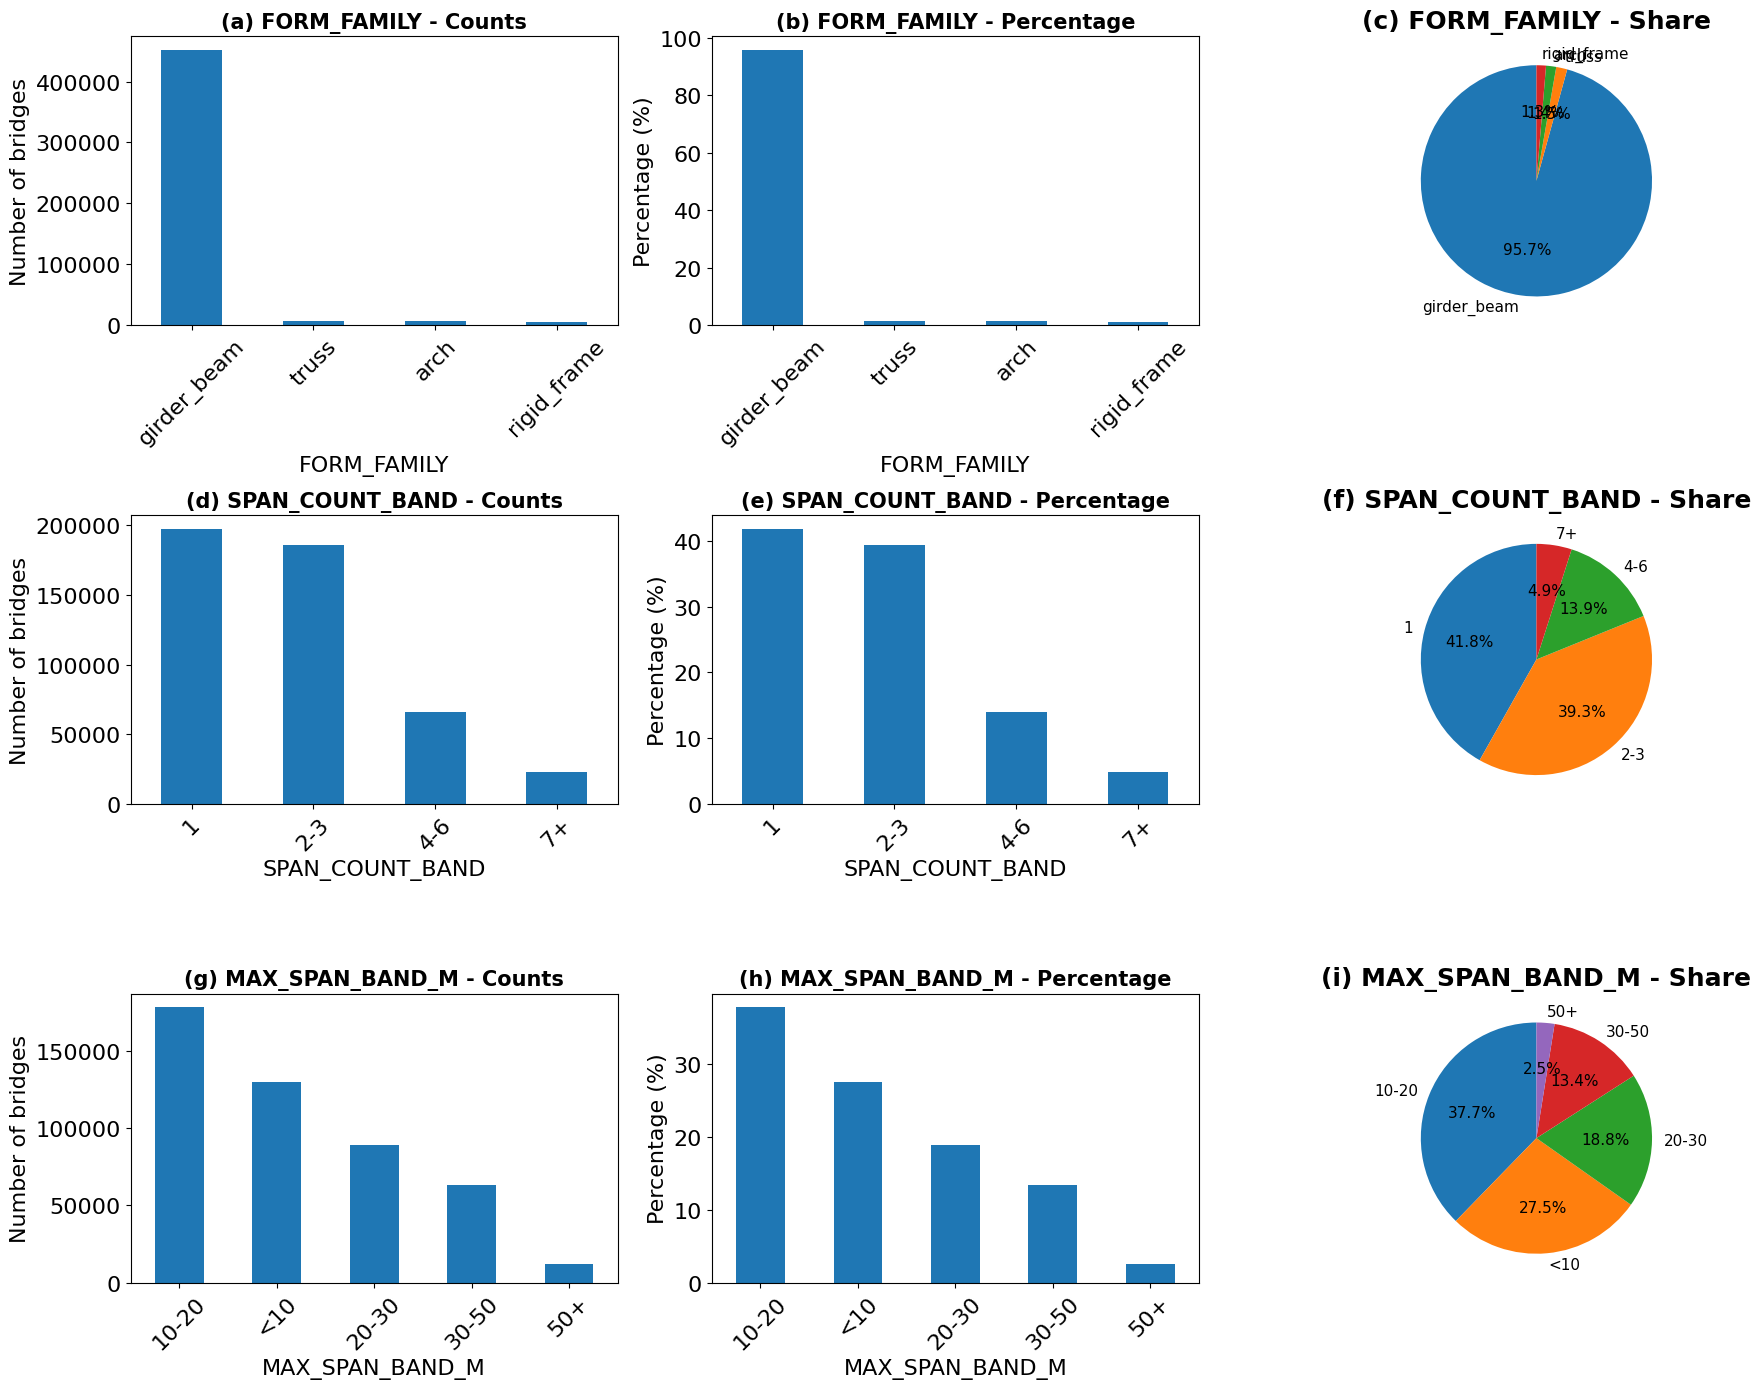

In [6]:
# -------------------------------------------------
# 8.2 Target distributions on a 3x3 grid
#      with larger labels and subplot letters
# -------------------------------------------------
target_cols = [TARGET_FORM, TARGET_SPANCOUNT, TARGET_MAXSPAN]

subplot_labels = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

plot_index = 0

for col in target_cols:
    counts = df_model[col].value_counts(dropna=False)
    perc = df_model[col].value_counts(normalize=True, dropna=False) * 100

    summary = pd.DataFrame({
        "count": counts,
        "percentage": perc.round(2)
    })

    print(f"\nDistribution of {col}:")
    print(summary)

    summary.to_csv(f"eda_outputs/{col}_distribution.csv")

    # Plot 1: frequency bar chart
    counts.plot(kind="bar", ax=axes[plot_index])
    axes[plot_index].set_title(
        f"{subplot_labels[plot_index]} {col} - Counts",
        fontsize=15,
        fontweight="bold"
    )
    axes[plot_index].set_xlabel(col, fontsize=16)
    axes[plot_index].set_ylabel("Number of bridges", fontsize=16)
    axes[plot_index].tick_params(axis="x", labelsize=16, rotation=45)
    axes[plot_index].tick_params(axis="y", labelsize=16)
    plot_index += 1

    # Plot 2: percentage bar chart
    perc.plot(kind="bar", ax=axes[plot_index])
    axes[plot_index].set_title(
        f"{subplot_labels[plot_index]} {col} - Percentage",
        fontsize=15,
        fontweight="bold"
    )
    axes[plot_index].set_xlabel(col, fontsize=16)
    axes[plot_index].set_ylabel("Percentage (%)", fontsize=16)
    axes[plot_index].tick_params(axis="x", labelsize=16, rotation=45)
    axes[plot_index].tick_params(axis="y", labelsize=16)
    plot_index += 1

    # Plot 3: pie chart
    counts.plot(
        kind="pie",
        ax=axes[plot_index],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 11}
    )
    axes[plot_index].set_title(
        f"{subplot_labels[plot_index]} {col} - Share",
        fontsize=18,
        fontweight="bold"
    )
    axes[plot_index].set_ylabel("")
    plot_index += 1

plt.tight_layout()
plt.savefig("eda_outputs/target_distributions_3x3_grid.png", dpi=300)
plt.show()

In [7]:
import numpy as np
import pandas as pd

import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


# ------------------------------------------------------------
# 1) Target mapping: NBI 43B -> form family for preliminary design
# ------------------------------------------------------------
def map_form_family(structure_type_43b) -> str:
    if pd.isna(structure_type_43b):
        return "other"
    try:
        t = int(structure_type_43b)
    except Exception:
        return "other"

    # Truss
    if t in (9, 10):
        return "truss"

    # Arch
    if t in (11, 12):
        return "arch"

    # Rigid frame
    if t == 7:
        return "rigid_frame"

    # Pragmatic beam/girder family (you can refine later)
    if t in (1, 2, 3, 4, 5, 6, 16, 17, 18, 20, 21, 22):
        return "girder_beam"

    return "other"


# ------------------------------------------------------------
# 2) Build + clean + stratified sample to exactly 10k
# ------------------------------------------------------------
def build_and_sample_10k(
    raw_csv_path: str,
    out_csv_path: str = "NBI_10k_prelim_design.csv",
    n_rows: int = 10_000,
    seed: int = 42
) -> pd.DataFrame:

    USECOLS = [
        "STATE_CODE_001",
        "STRUCTURE_NUMBER_008",
        "FUNCTIONAL_CLASS_026",
        "STRUCTURE_LEN_MT_049",
        "MAX_SPAN_LEN_MT_048",
        "MAIN_UNIT_SPANS_045",
        "DECK_WIDTH_MT_052",
        "APPR_WIDTH_MT_032",
        "DEGREES_SKEW_034",
        "ADT_029",
        "PERCENT_ADT_TRUCK_109",
        "TRAFFIC_LANES_ON_028A",
        "YEAR_BUILT_027",
        "STRUCTURE_TYPE_043B",
    ]

    df = pd.read_csv(raw_csv_path, usecols=USECOLS, low_memory=False)

    # numeric coercion
    num_cols = [
        "FUNCTIONAL_CLASS_026",
        "STRUCTURE_LEN_MT_049", "MAX_SPAN_LEN_MT_048", "MAIN_UNIT_SPANS_045",
        "DECK_WIDTH_MT_052", "APPR_WIDTH_MT_032", "DEGREES_SKEW_034",
        "ADT_029", "PERCENT_ADT_TRUCK_109", "TRAFFIC_LANES_ON_028A",
        "YEAR_BUILT_027", "STRUCTURE_TYPE_043B",
    ]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # drop missing essentials
    df = df.dropna(subset=[
        "STRUCTURE_LEN_MT_049",
        "MAX_SPAN_LEN_MT_048",
        "MAIN_UNIT_SPANS_045",
        "DECK_WIDTH_MT_052",
        "ADT_029",
        "STRUCTURE_TYPE_043B"
    ])

    # plausibility filters
    df = df[
        (df["STRUCTURE_LEN_MT_049"] > 0) &
        (df["MAX_SPAN_LEN_MT_048"] > 0) &
        (df["MAIN_UNIT_SPANS_045"] >= 1) &
        (df["DECK_WIDTH_MT_052"] > 0) &
        (df["ADT_029"] >= 0)
    ].copy()

    # target
    df["FORM_FAMILY"] = df["STRUCTURE_TYPE_043B"].apply(map_form_family)

    # keep only core families
    df = df[df["FORM_FAMILY"].isin(["girder_beam", "truss", "arch", "rigid_frame"])].copy()

    if len(df) < n_rows:
        raise RuntimeError(
            f"After cleaning, only {len(df)} rows remain; cannot sample {n_rows}. "
            "Reduce n_rows or relax filters."
        )

    # ---- stratified sample to exactly n_rows ----
    y = df["FORM_FAMILY"].values
    classes, counts = np.unique(y, return_counts=True)
    proportions = counts / counts.sum()

    desired = np.floor(proportions * n_rows).astype(int)
    remainder = n_rows - desired.sum()

    fractional = (proportions * n_rows) - np.floor(proportions * n_rows)
    order = np.argsort(-fractional)
    for i in range(remainder):
        desired[order[i % len(order)]] += 1

    parts = []
    for cls, n_cls in zip(classes, desired):
        g = df[df["FORM_FAMILY"] == cls]
        parts.append(g.sample(n=n_cls, random_state=seed))

    df_10k = pd.concat(parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    df_10k.to_csv(out_csv_path, index=False)

    print("Saved:", out_csv_path)
    print("Rows:", len(df_10k))
    print("Class counts:\n", df_10k["FORM_FAMILY"].value_counts())

    return df_10k


# ------------------------------------------------------------
# 3) Optuna + 10-fold CV with CatBoost
# ------------------------------------------------------------
def run_catboost_optuna_10fold(
    df: pd.DataFrame,
    n_trials: int = 40,
    seed: int = 42
) -> None:

    FEATURES = [
        "STRUCTURE_LEN_MT_049",
        "MAX_SPAN_LEN_MT_048",
        "MAIN_UNIT_SPANS_045",
        "DECK_WIDTH_MT_052",
        "APPR_WIDTH_MT_032",
        "DEGREES_SKEW_034",
        "ADT_029",
        "PERCENT_ADT_TRUCK_109",
        "TRAFFIC_LANES_ON_028A",
        "YEAR_BUILT_027",
        "FUNCTIONAL_CLASS_026",
    ]
    TARGET = "FORM_FAMILY"

    X = df[FEATURES].copy()
    y = df[TARGET].astype(str).values

    # CatBoost can handle missing values; we’ll keep them as-is.
    # If you want, you can still fill NaNs for stability, but it’s not required.

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    def objective(trial: optuna.Trial) -> float:
        bootstrap_type = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"])

        params = {
            "loss_function": "MultiClass",
            "random_seed": seed,
            "verbose": 0,

            "iterations": trial.suggest_int("iterations", 300, 2000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 50.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),

            # feature sampling is okay
            "rsm": trial.suggest_float("rsm", 0.6, 1.0),

            # early stopping
            "od_type": "Iter",
            "od_wait": trial.suggest_int("od_wait", 30, 120),

            # bootstrap choice
            "bootstrap_type": bootstrap_type,
        }

        # ---- compatibility rules ----
        if bootstrap_type == "Bayesian":
            params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 2.0)
            # DO NOT set subsample here
        else:  # Bernoulli
            params["subsample"] = trial.suggest_float("subsample", 0.6, 1.0)
            # DO NOT set bagging_temperature here

        fold_f1 = []
        for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y[tr_idx], y[va_idx]

            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)

            pred = model.predict(X_va).reshape(-1)
            f1 = f1_score(y_va, pred, average="macro")
            fold_f1.append(f1)

            trial.report(float(np.mean(fold_f1)), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return float(np.mean(fold_f1))


    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("\nBest mean macro-F1 (10-fold):", study.best_value)
    print("Best hyperparameters:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")


# ------------------------------------------------------------
# 4) Main
# ------------------------------------------------------------
def main():
    RAW = "NTAD_National_Bridge_Inventory_-6282134062105639862.csv"

    df_10k = build_and_sample_10k(
        raw_csv_path=RAW,
        out_csv_path="NBI_10k_prelim_design.csv",
        n_rows=10_000,
        seed=42
    )

    run_catboost_optuna_10fold(df_10k, n_trials=40, seed=42)


if __name__ == "__main__":
    main()


[I 2026-01-31 13:16:37,846] A new study created in memory with name: no-name-6717908c-717c-4b78-bdfd-2013d9469072


Saved: NBI_10k_prelim_design.csv
Rows: 10000
Class counts:
 FORM_FAMILY
girder_beam    9571
truss           154
arch            142
rigid_frame     133
Name: count, dtype: int64


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-01-31 13:16:56,265] Trial 0 finished with value: 0.47702020305923903 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 1545, 'learning_rate': 0.07661100707771368, 'depth': 5, 'l2_leaf_reg': 0.037758875456826865, 'random_strength': 0.11616722433639892, 'rsm': 0.9464704583099741, 'od_wait': 84, 'subsample': 0.8832290311184181}. Best is trial 0 with value: 0.47702020305923903.
[I 2026-01-31 13:17:54,973] Trial 1 finished with value: 0.4683420339085883 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 1715, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 0.0476878541548261, 'random_strength': 0.6084844859190754, 'rsm': 0.8099025726528951, 'od_wait': 69, 'subsample': 0.7164916560792167}. Best is trial 0 with value: 0.47702020305923903.
[I 2026-01-31 13:19:54,998] Trial 2 finished with value: 0.4557831966202969 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 796, 'learning_rate': 0.03476649150592621, 'depth': 7, 'l2_leaf_reg': 8.

[I 2026-01-31 13:51:53,746] Trial 27 pruned. 
[I 2026-01-31 13:51:55,593] Trial 28 pruned. 
[I 2026-01-31 13:52:15,424] Trial 29 finished with value: 0.4772372433129646 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 1657, 'learning_rate': 0.07528533833182981, 'depth': 5, 'l2_leaf_reg': 0.08735326416513921, 'random_strength': 0.0016021802003348337, 'rsm': 0.9547334150895267, 'od_wait': 73, 'subsample': 0.7449027256952441}. Best is trial 4 with value: 0.4863566728009426.
[I 2026-01-31 13:53:21,052] Trial 30 finished with value: 0.46444269917524295 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 747, 'learning_rate': 0.09177727684266991, 'depth': 7, 'l2_leaf_reg': 4.227724836162131, 'random_strength': 0.5024422473777188, 'rsm': 0.7423558373932798, 'od_wait': 82, 'subsample': 0.9607107609980723}. Best is trial 4 with value: 0.4863566728009426.
[I 2026-01-31 13:53:38,819] Trial 31 finished with value: 0.47770691141065524 and parameters: {'bootstrap_type': 'Berno

Training records: 8000
Testing records: 2000

Training class distribution:
FORM_FAMILY
girder_beam    7657
truss           123
arch            114
rigid_frame     106
Name: count, dtype: int64

Testing class distribution:
FORM_FAMILY
girder_beam    1914
truss            31
arch             28
rigid_frame      27
Name: count, dtype: int64
0:	learn: 0.8724189	test: 0.8746926	best: 0.8746926 (0)	total: 152ms	remaining: 54.4s
100:	learn: 0.0930069	test: 0.1161281	best: 0.1161281 (100)	total: 718ms	remaining: 1.83s
200:	learn: 0.0728490	test: 0.1130962	best: 0.1128242 (196)	total: 1.18s	remaining: 923ms
300:	learn: 0.0566188	test: 0.1130236	best: 0.1114136 (244)	total: 1.62s	remaining: 307ms
Stopped by overfitting detector  (79 iterations wait)

bestTest = 0.1114136377
bestIteration = 244

Shrink model to first 245 iterations.

Final Test Accuracy: 0.9645
Final Test Macro-F1: 0.5352
Final Test Weighted-F1: 0.9569

Classification Report:
              precision    recall  f1-score   support


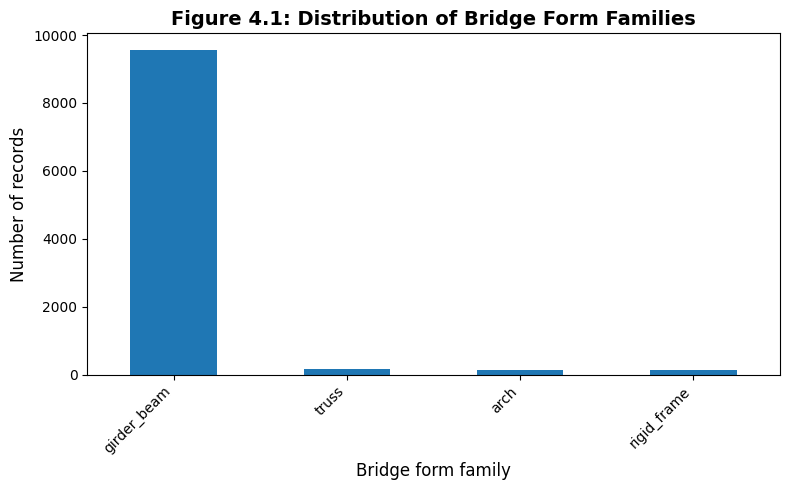

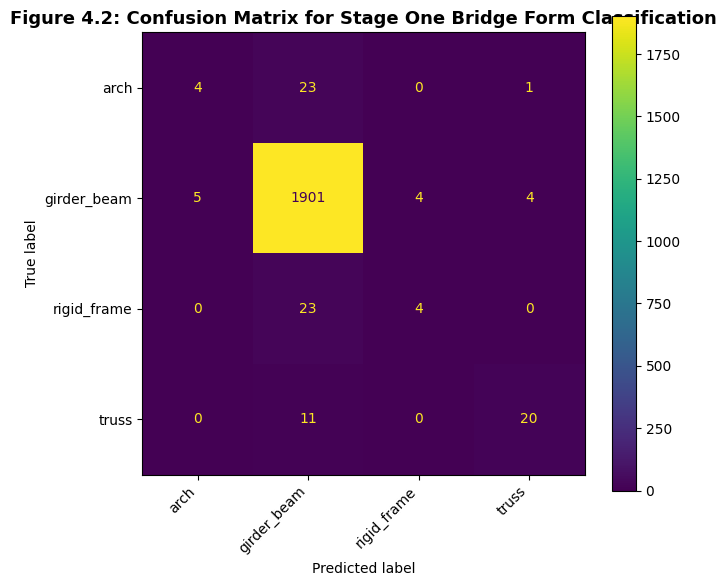

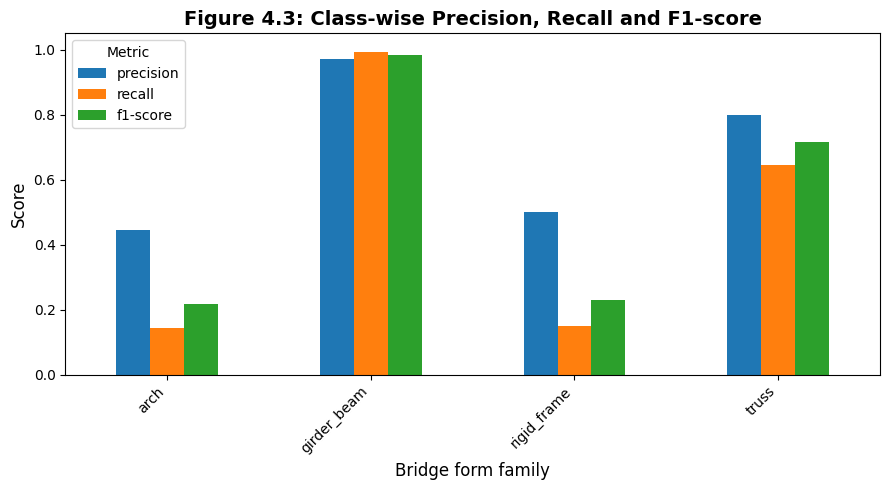

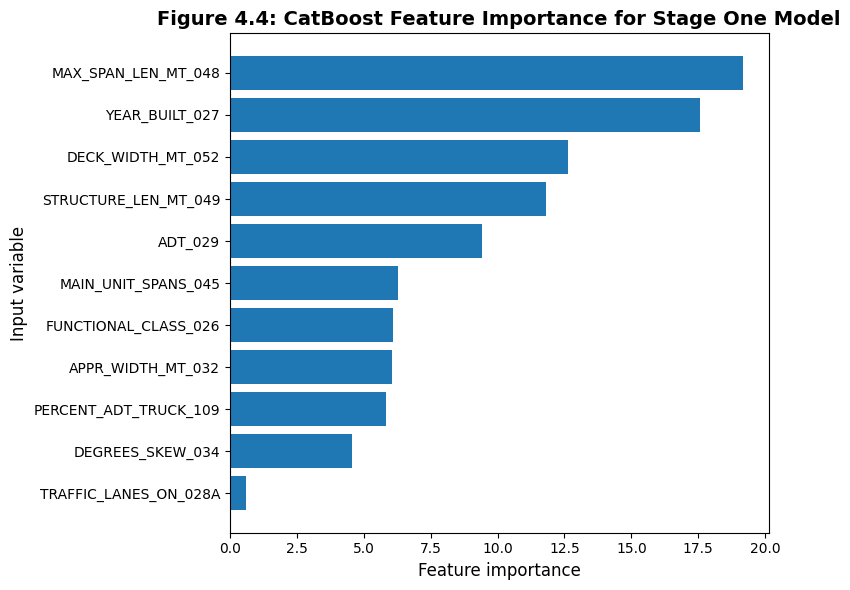

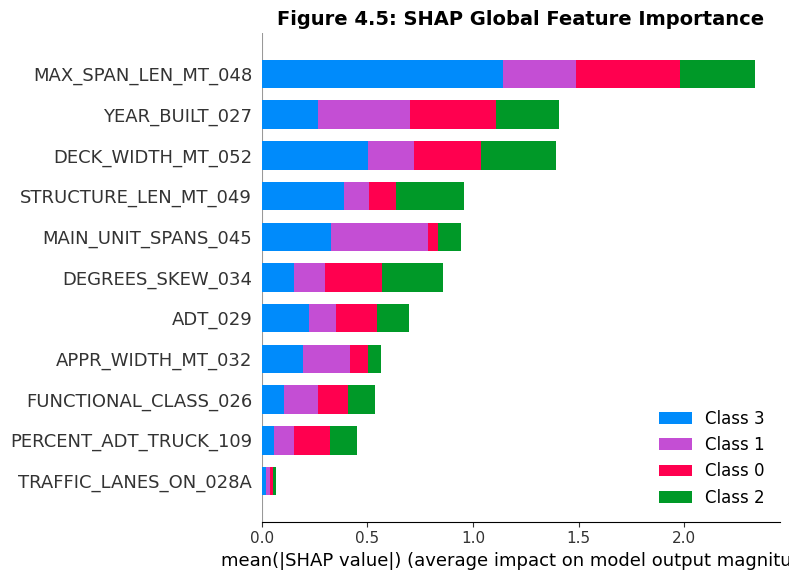

<Figure size 640x480 with 0 Axes>

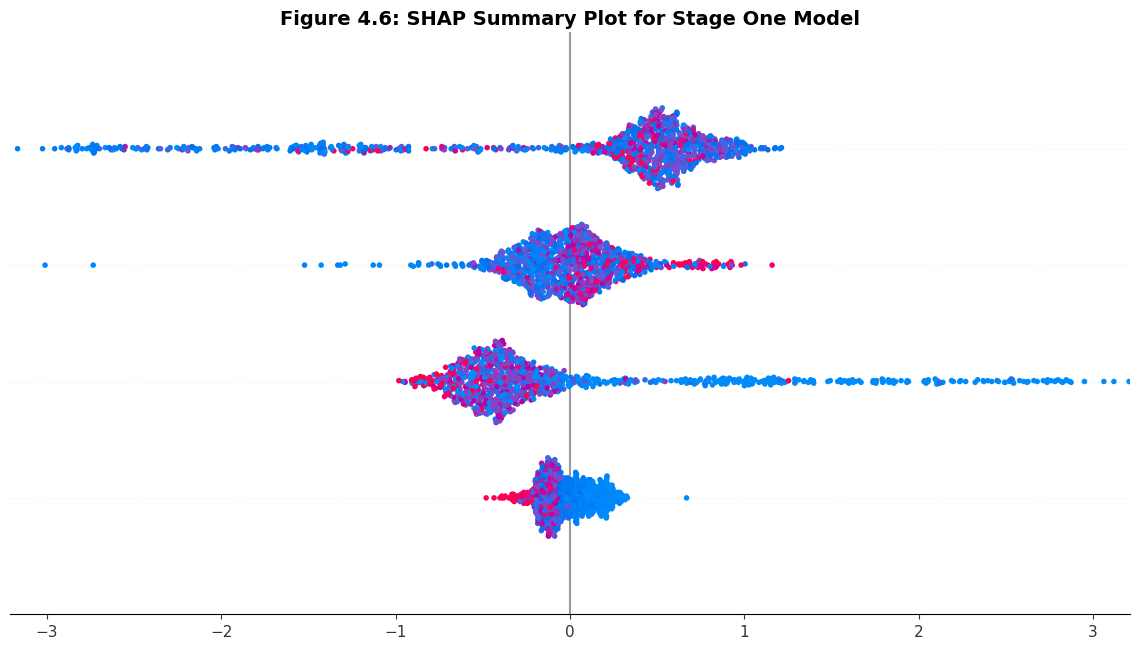


Saved final model and Chapter 4 outputs in: chapter4_outputs/


In [7]:
# ============================================================
# Final CatBoost Model Training + Chapter 4 Figures
# Target: FORM_FAMILY
# Using best Optuna hyperparameters
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

# Optional SHAP
import shap

# ------------------------------------------------------------
# 1) Create output folder
# ------------------------------------------------------------
os.makedirs("chapter4_outputs", exist_ok=True)

# ------------------------------------------------------------
# 2) Load the final 10k modelling dataset
# ------------------------------------------------------------
df = pd.read_csv("NBI_10k_prelim_design.csv")

FEATURES = [
    "STRUCTURE_LEN_MT_049",
    "MAX_SPAN_LEN_MT_048",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "APPR_WIDTH_MT_032",
    "DEGREES_SKEW_034",
    "ADT_029",
    "PERCENT_ADT_TRUCK_109",
    "TRAFFIC_LANES_ON_028A",
    "YEAR_BUILT_027",
    "FUNCTIONAL_CLASS_026",
]

TARGET = "FORM_FAMILY"

X = df[FEATURES].copy()
y = df[TARGET].astype(str).copy()

# ------------------------------------------------------------
# 3) Train-test split for final model assessment
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

# ------------------------------------------------------------
# 4) Best CatBoost hyperparameters from Optuna
# ------------------------------------------------------------
best_params = {
    "loss_function": "MultiClass",
    "bootstrap_type": "Bernoulli",
    "iterations": 358,
    "learning_rate": 0.22038218939289875,
    "depth": 5,
    "l2_leaf_reg": 2.8226046783939607,
    "random_strength": 0.6234221521788219,
    "rsm": 0.8080272084711243,
    "od_type": "Iter",
    "od_wait": 79,
    "subsample": 0.6739417822102108,
    "random_seed": 42,
    "verbose": 100
}

# ------------------------------------------------------------
# 5) Train final model
# ------------------------------------------------------------
final_model = CatBoostClassifier(**best_params)

final_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# ------------------------------------------------------------
# 6) Predictions and metrics
# ------------------------------------------------------------
y_pred = final_model.predict(X_test).reshape(-1)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\nFinal Test Accuracy:", round(accuracy, 4))
print("Final Test Macro-F1:", round(macro_f1, 4))
print("Final Test Weighted-F1:", round(weighted_f1, 4))

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv("chapter4_outputs/classification_report_stage1.csv")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# 7) Figure 4.1: Class distribution
# ------------------------------------------------------------
class_counts = y.value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Figure 4.1: Distribution of Bridge Form Families", fontsize=14, fontweight="bold")
plt.xlabel("Bridge form family", fontsize=12)
plt.ylabel("Number of records", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chapter4_outputs/figure_4_1_class_distribution.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 8) Figure 4.2: Confusion matrix
# ------------------------------------------------------------
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap=None, values_format="d")
plt.title("Figure 4.2: Confusion Matrix for Stage One Bridge Form Classification",
          fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chapter4_outputs/figure_4_2_confusion_matrix.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 9) Figure 4.3: Class-wise precision, recall and F1-score
# ------------------------------------------------------------
metrics_df = report_df.loc[labels, ["precision", "recall", "f1-score"]]

ax = metrics_df.plot(kind="bar", figsize=(9, 5))
plt.title("Figure 4.3: Class-wise Precision, Recall and F1-score",
          fontsize=14, fontweight="bold")
plt.xlabel("Bridge form family", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig("chapter4_outputs/figure_4_3_classwise_metrics.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 10) Figure 4.4: CatBoost feature importance
# ------------------------------------------------------------
feature_importance = final_model.get_feature_importance()
fi_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": feature_importance
}).sort_values("importance", ascending=True)

fi_df.to_csv("chapter4_outputs/catboost_feature_importance_stage1.csv", index=False)

plt.figure(figsize=(8, 6))
plt.barh(fi_df["feature"], fi_df["importance"])
plt.title("Figure 4.4: CatBoost Feature Importance for Stage One Model",
          fontsize=14, fontweight="bold")
plt.xlabel("Feature importance", fontsize=12)
plt.ylabel("Input variable", fontsize=12)
plt.tight_layout()
plt.savefig("chapter4_outputs/figure_4_4_catboost_feature_importance.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 11) SHAP analysis
# ------------------------------------------------------------
# Use a smaller sample for SHAP if needed to reduce computation
X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# ------------------------------------------------------------
# 12) Figure 4.5: SHAP global bar plot
# ------------------------------------------------------------
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    plot_type="bar",
    show=False
)
plt.title("Figure 4.5: SHAP Global Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chapter4_outputs/figure_4_5_shap_global_importance.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 13) Figure 4.6: SHAP summary plot
# ------------------------------------------------------------
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    show=False
)
plt.title("Figure 4.6: SHAP Summary Plot for Stage One Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chapter4_outputs/figure_4_6_shap_summary_plot.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 14) Save model
# ------------------------------------------------------------
final_model.save_model("chapter4_outputs/final_catboost_stage1_form_family_model.cbm")

print("\nSaved final model and Chapter 4 outputs in: chapter4_outputs/")


Class: arch
Class SHAP shape: (1000, 11)


<Figure size 800x600 with 0 Axes>

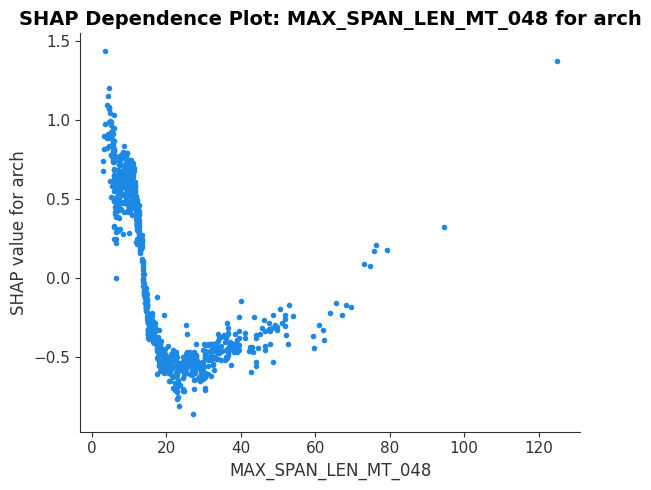

<Figure size 800x600 with 0 Axes>

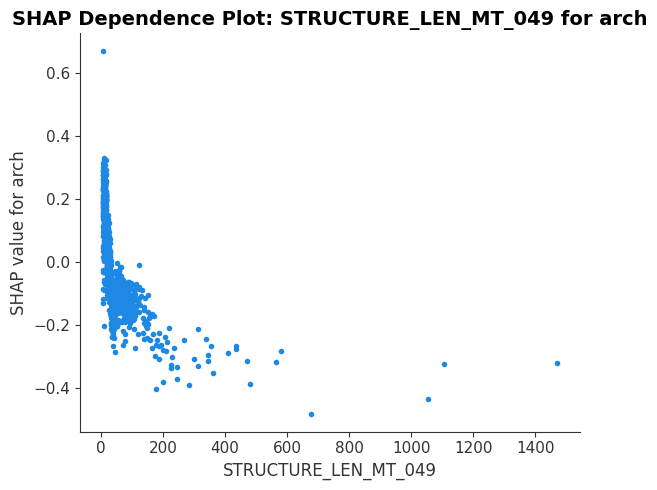

<Figure size 800x600 with 0 Axes>

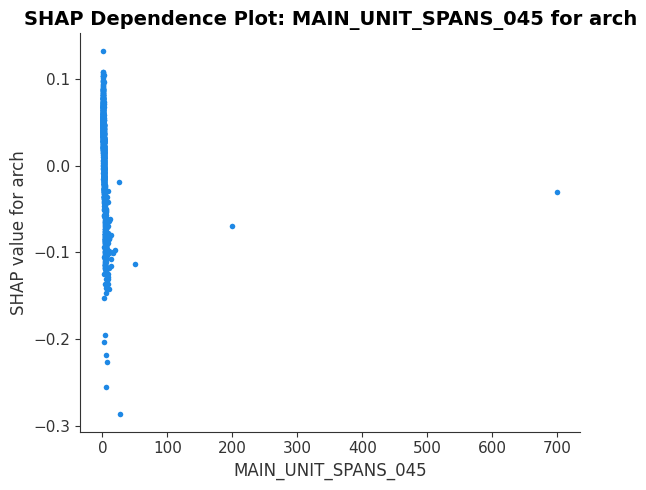

<Figure size 800x600 with 0 Axes>

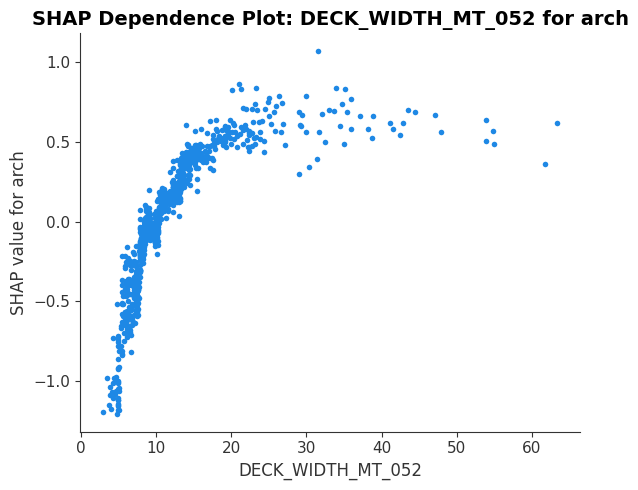

<Figure size 800x600 with 0 Axes>

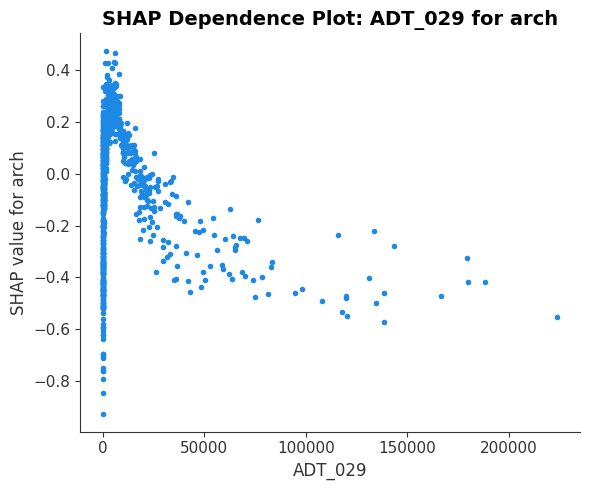

<Figure size 800x600 with 0 Axes>

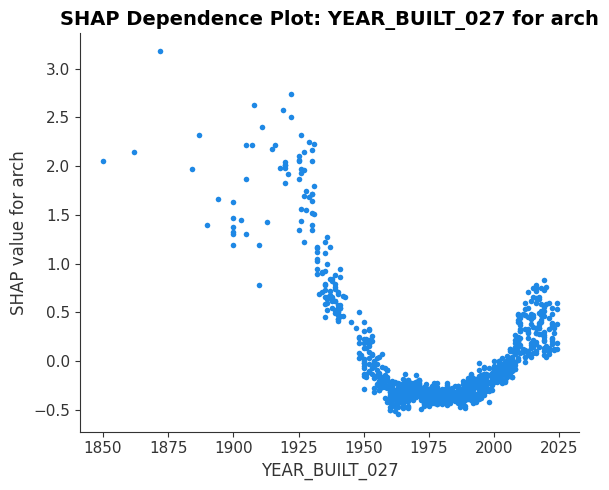


Class: girder_beam
Class SHAP shape: (1000, 11)


<Figure size 800x600 with 0 Axes>

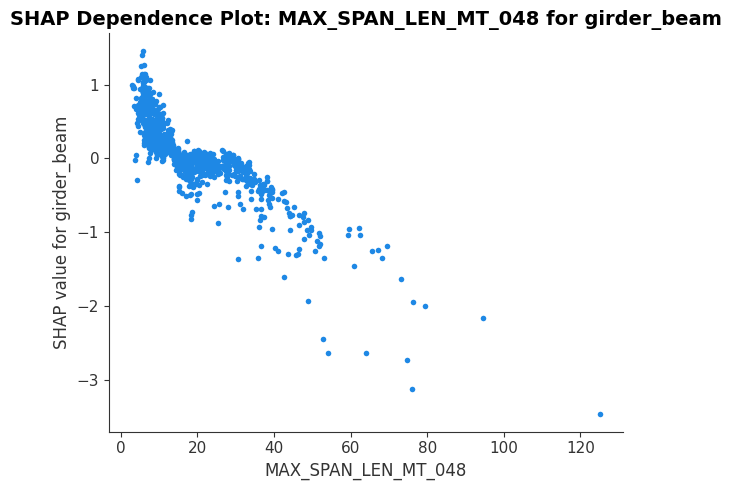

<Figure size 800x600 with 0 Axes>

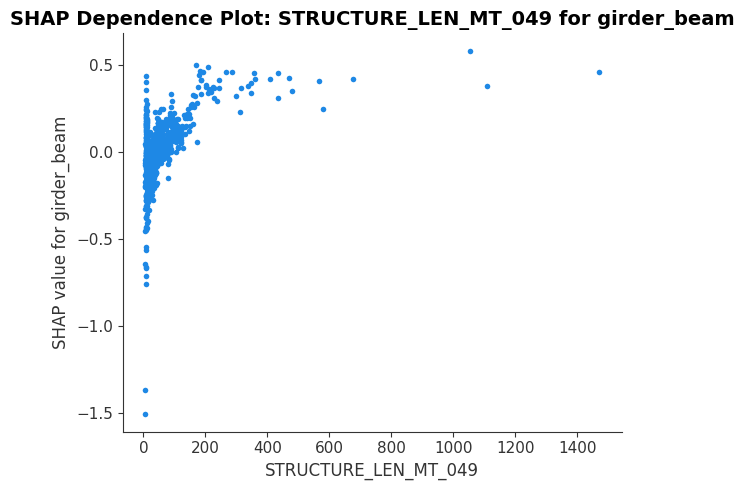

<Figure size 800x600 with 0 Axes>

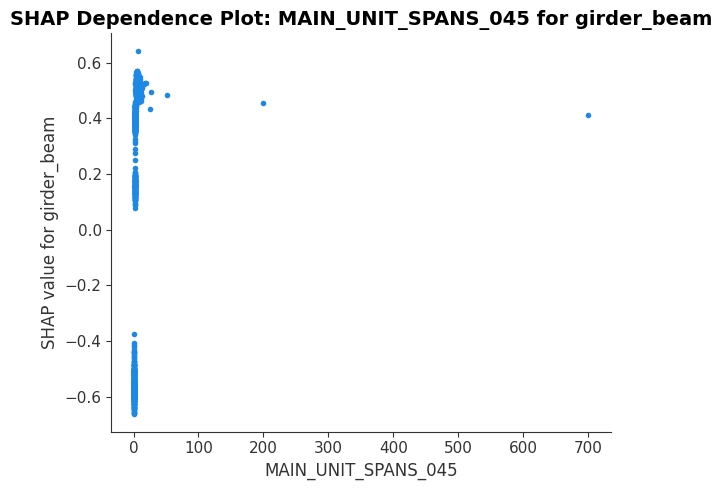

<Figure size 800x600 with 0 Axes>

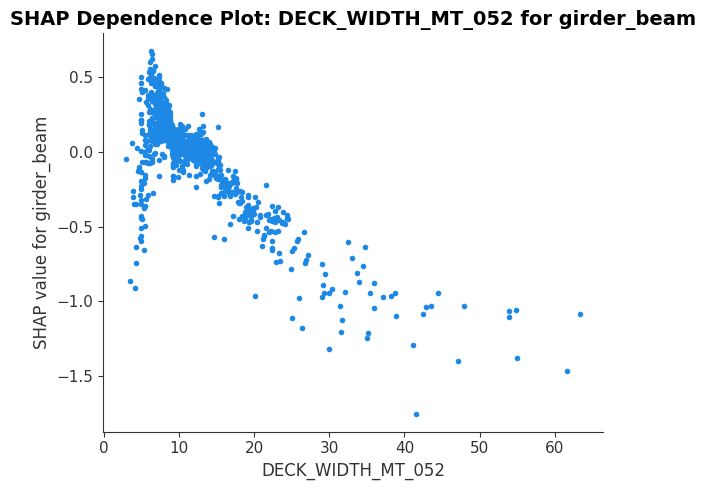

<Figure size 800x600 with 0 Axes>

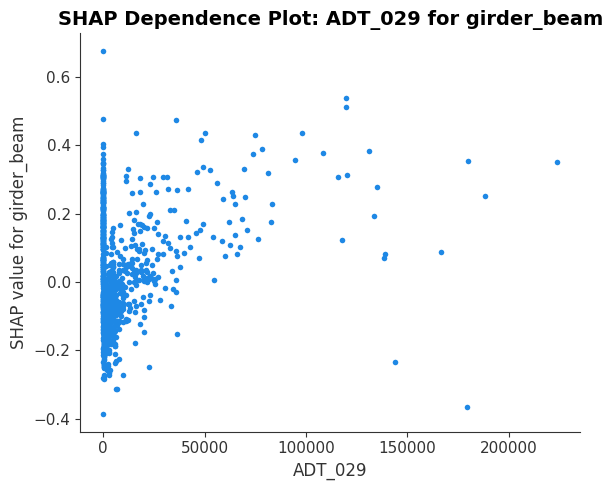

<Figure size 800x600 with 0 Axes>

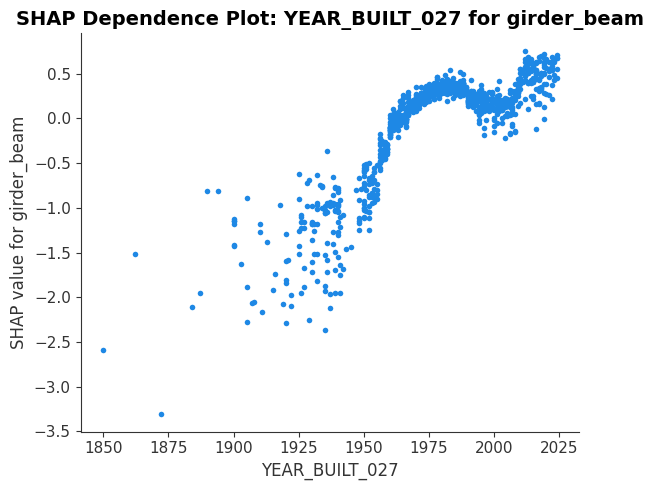


Class: rigid_frame
Class SHAP shape: (1000, 11)


<Figure size 800x600 with 0 Axes>

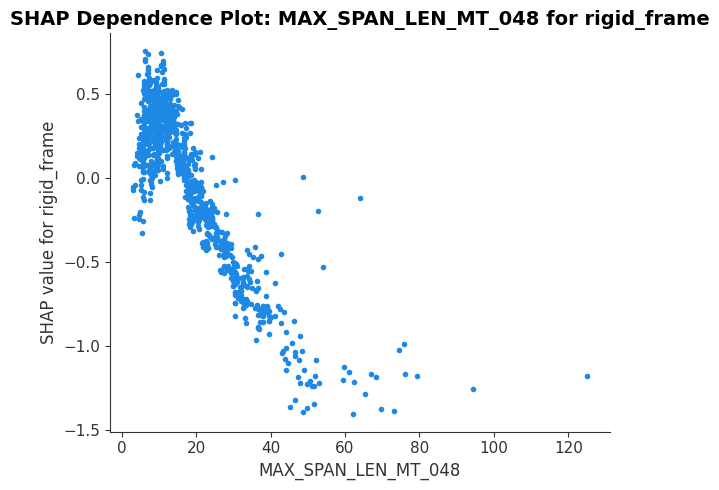

<Figure size 800x600 with 0 Axes>

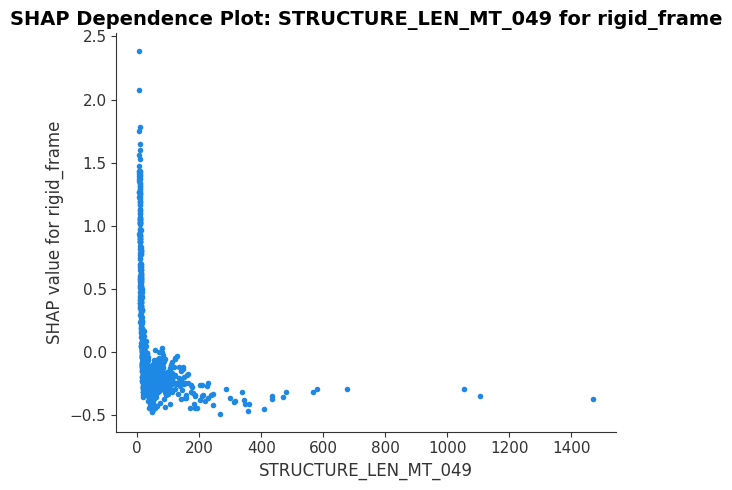

<Figure size 800x600 with 0 Axes>

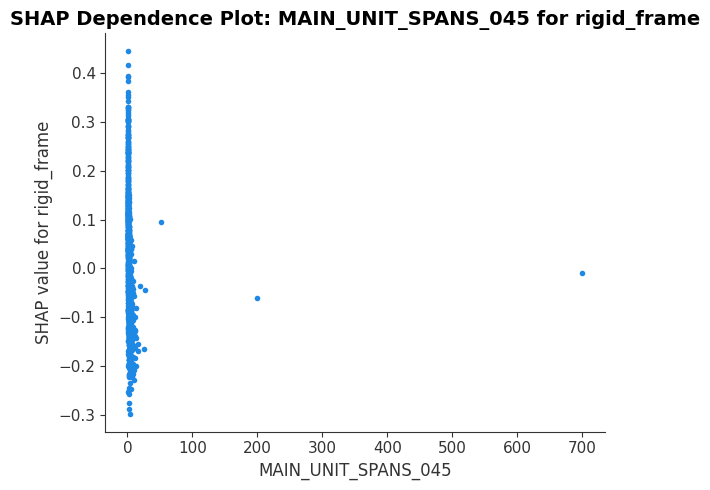

<Figure size 800x600 with 0 Axes>

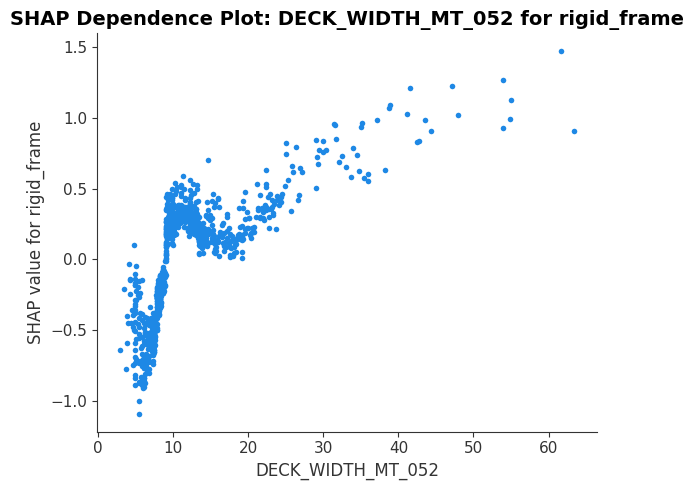

<Figure size 800x600 with 0 Axes>

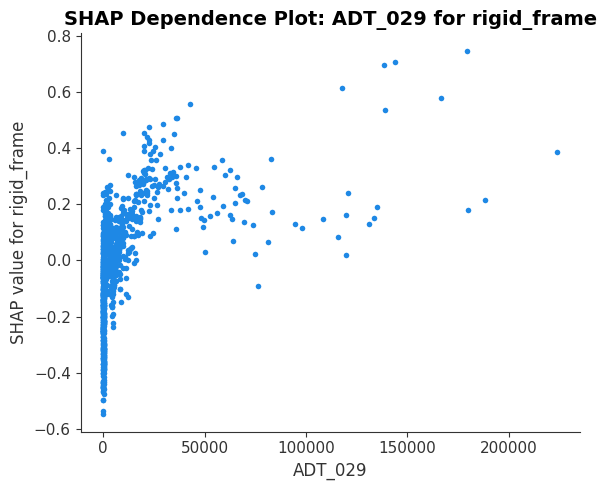

<Figure size 800x600 with 0 Axes>

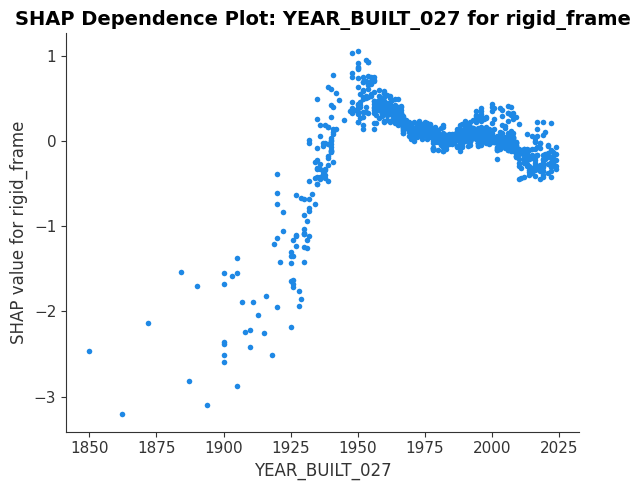


Class: truss
Class SHAP shape: (1000, 11)


<Figure size 800x600 with 0 Axes>

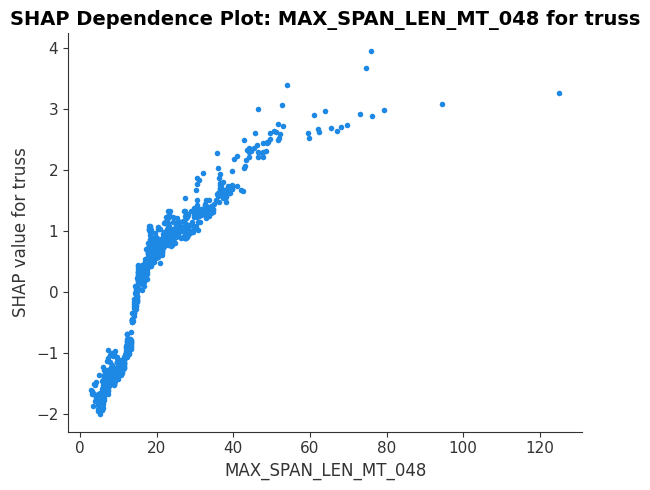

<Figure size 800x600 with 0 Axes>

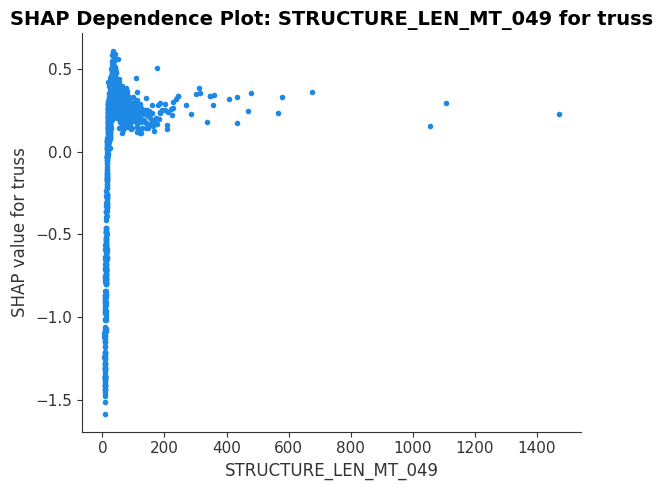

<Figure size 800x600 with 0 Axes>

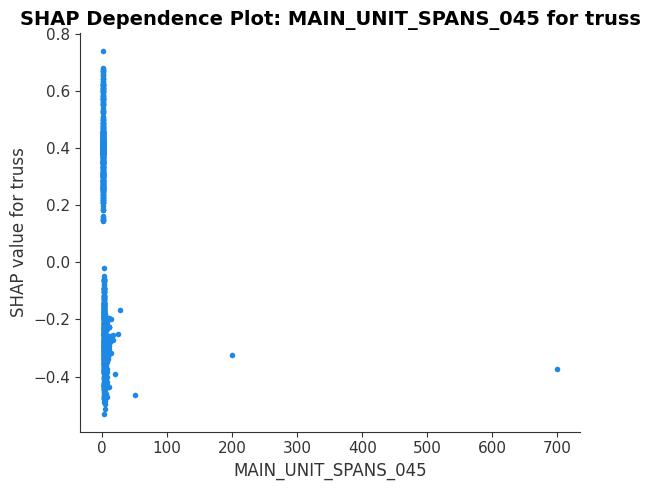

<Figure size 800x600 with 0 Axes>

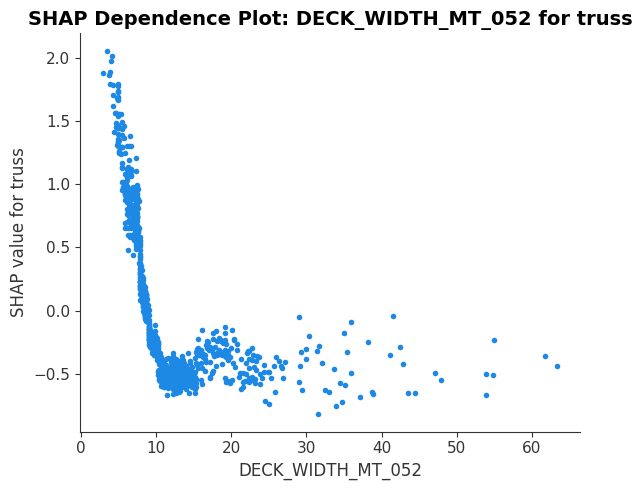

<Figure size 800x600 with 0 Axes>

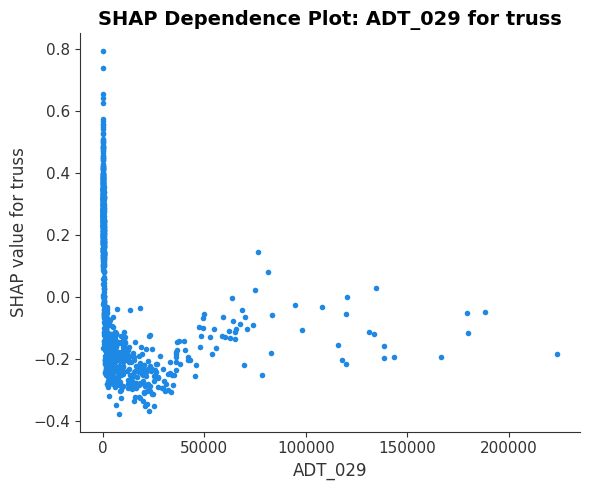

<Figure size 800x600 with 0 Axes>

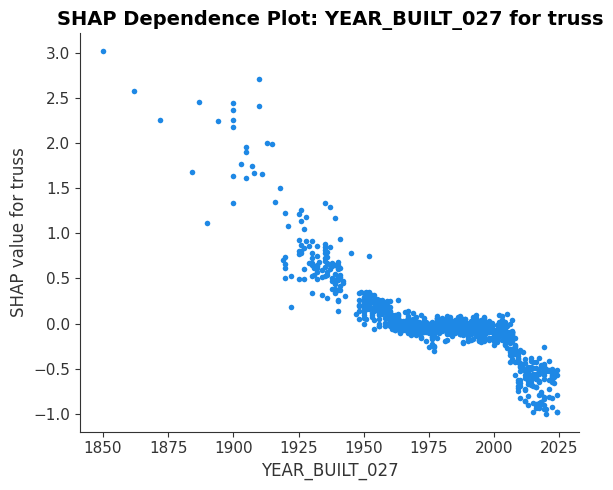

In [9]:
# ------------------------------------------------------------
# SHAP dependency plots for multi-class CatBoost
# ------------------------------------------------------------

dependency_features = [
    "MAX_SPAN_LEN_MT_048",
    "STRUCTURE_LEN_MT_049",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "ADT_029",
    "YEAR_BUILT_027"
]

class_names = list(final_model.classes_)

# Convert SHAP values into class-specific 2D arrays
# Each class-specific array should have shape: n_samples x n_features
shap_by_class = {}

if isinstance(shap_values, list):
    # Older SHAP format: list of arrays, one per class
    for class_index, class_name in enumerate(class_names):
        shap_by_class[class_name] = shap_values[class_index]

else:
    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        # Common multi-class format: n_samples x n_features x n_classes
        if shap_array.shape[1] == len(FEATURES):
            for class_index, class_name in enumerate(class_names):
                shap_by_class[class_name] = shap_array[:, :, class_index]

        # Alternative format: n_classes x n_samples x n_features
        elif shap_array.shape[2] == len(FEATURES):
            for class_index, class_name in enumerate(class_names):
                shap_by_class[class_name] = shap_array[class_index, :, :]

        else:
            raise ValueError(f"Unexpected SHAP array shape: {shap_array.shape}")

    elif shap_array.ndim == 2:
        # Binary/single-output format
        shap_by_class[class_names[0]] = shap_array

    else:
        raise ValueError(f"Unexpected SHAP array dimensions: {shap_array.ndim}")

# ------------------------------------------------------------
# Produce dependency plots
# ------------------------------------------------------------
for class_name in class_names:

    class_shap_values = shap_by_class[class_name]

    print(f"\nClass: {class_name}")
    print("Class SHAP shape:", class_shap_values.shape)

    for feature in dependency_features:

        plt.figure(figsize=(8, 6))

        shap.dependence_plot(
            ind=feature,
            shap_values=class_shap_values,
            features=X_shap,
            feature_names=FEATURES,
            interaction_index=None,   # avoids interaction-index errors
            show=False
        )

        plt.title(
            f"SHAP Dependence Plot: {feature} for {class_name}",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel(feature, fontsize=12)
        plt.ylabel(f"SHAP value for {class_name}", fontsize=12)
        plt.tight_layout()

        safe_feature = feature.replace("/", "_").replace(" ", "_")
        safe_class = str(class_name).replace("/", "_").replace(" ", "_")

        plt.savefig(
            f"chapter4_outputs/shap_dependence_{safe_feature}_{safe_class}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

SHAP array shape: (1000, 11, 4)
X_shap shape: (1000, 11)
Top 9 SHAP features:
1. MAX_SPAN_LEN_MT_048
2. YEAR_BUILT_027
3. DECK_WIDTH_MT_052
4. STRUCTURE_LEN_MT_049
5. MAIN_UNIT_SPANS_045
6. DEGREES_SKEW_034
7. ADT_029
8. APPR_WIDTH_MT_032
9. FUNCTIONAL_CLASS_026


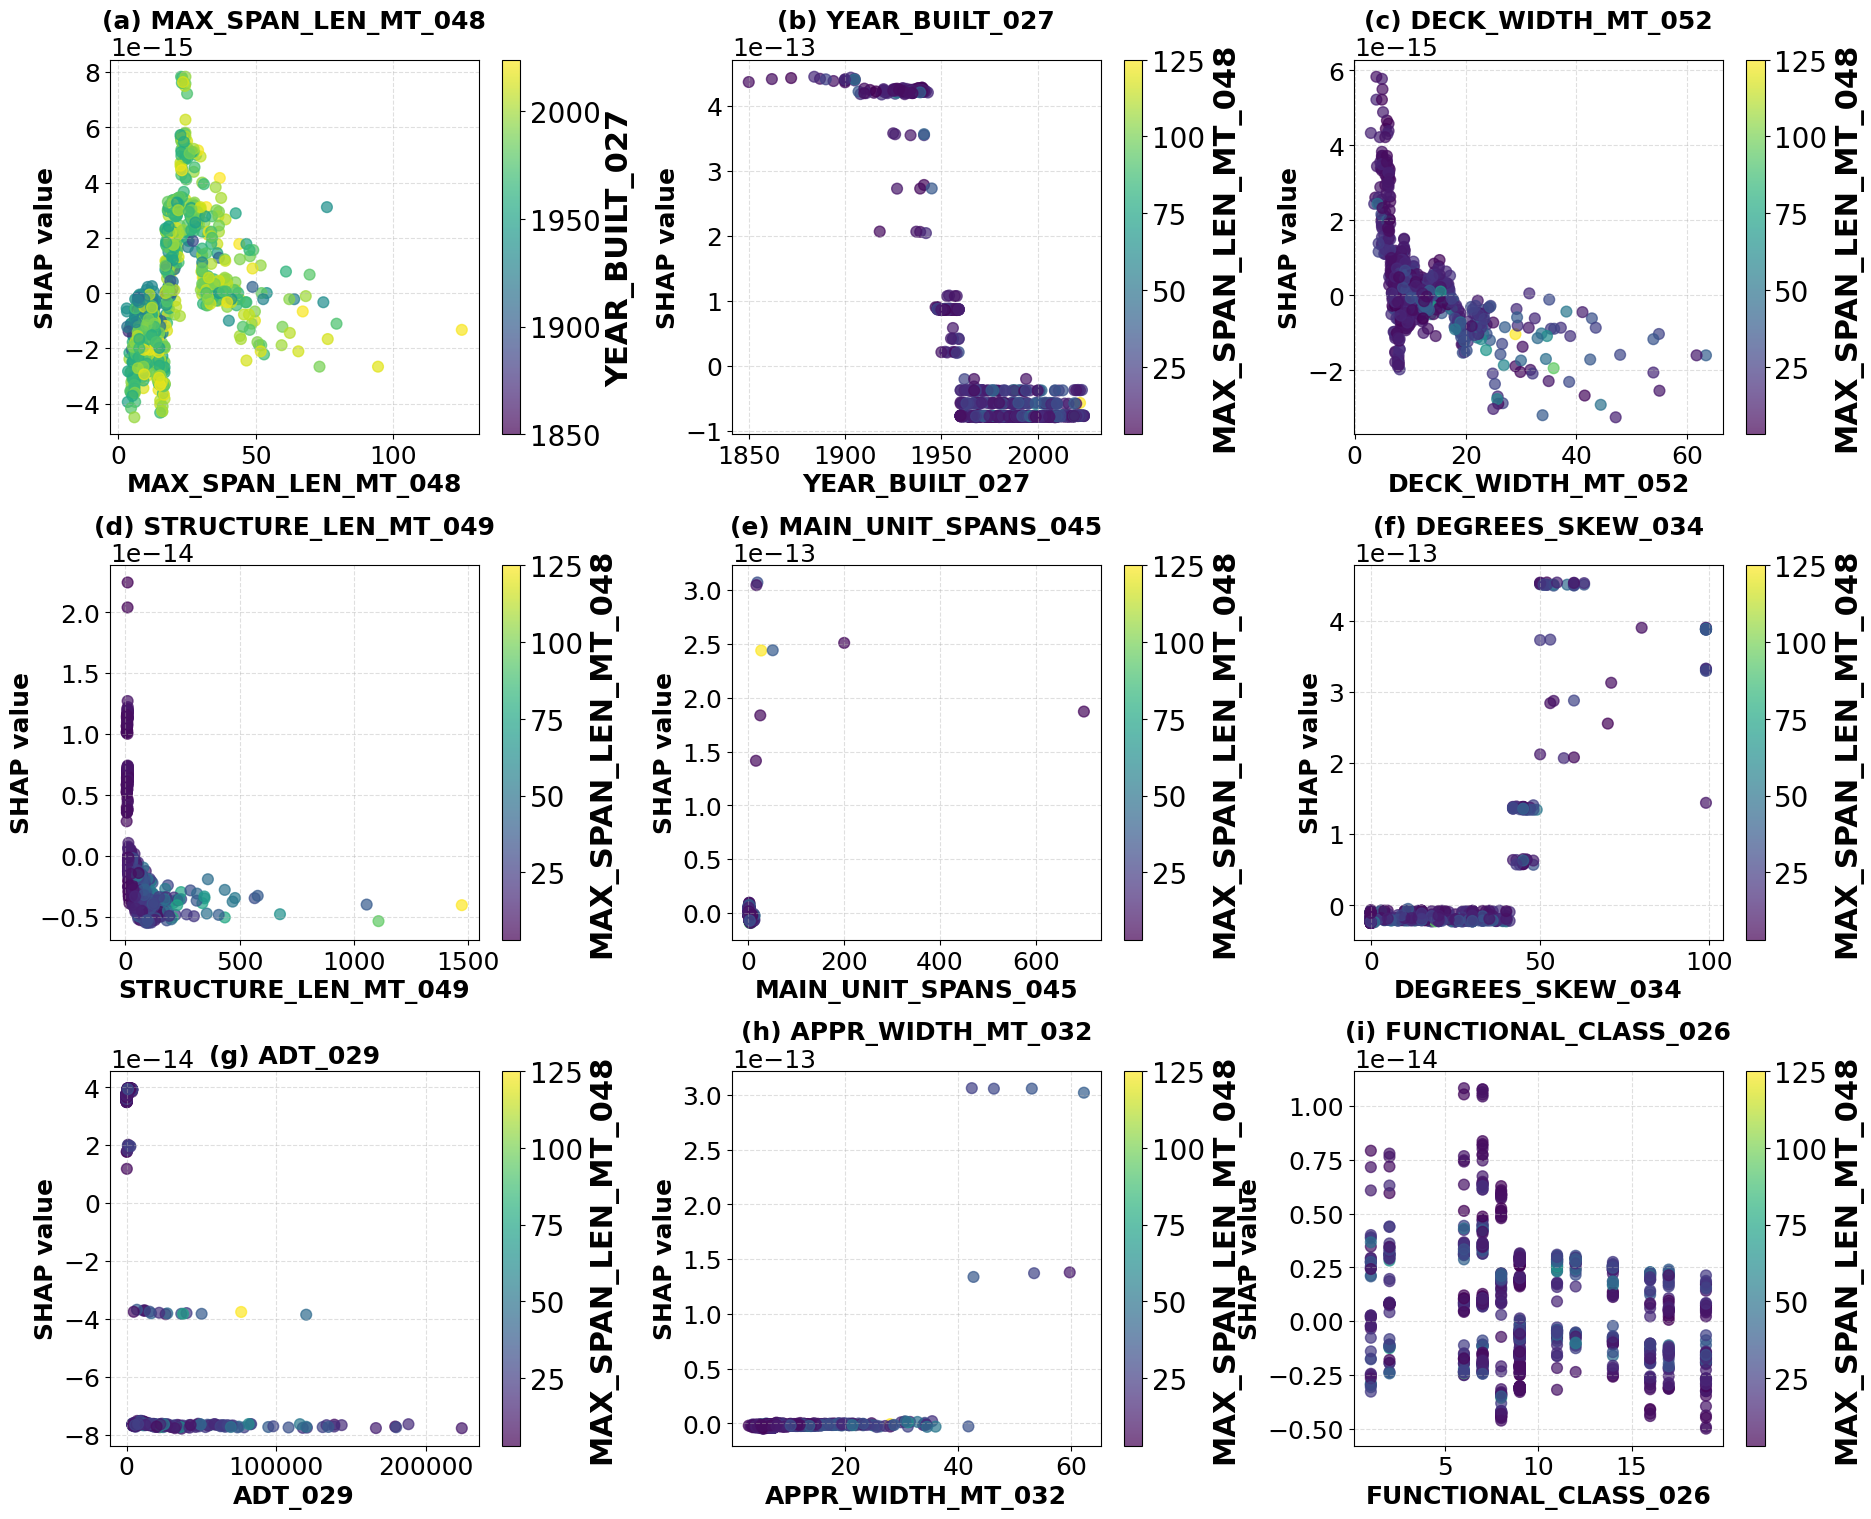

Saved:
chapter4_outputs/SHAP_dependence_interaction_top9_3x3.pdf
chapter4_outputs/SHAP_dependence_interaction_top9_3x3.png


In [11]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ============================================================
# SHAP DEPENDENCE / INTERACTION PLOTS: 3×3 GRID
# For multi-class CatBoost Stage One model
# ============================================================

os.makedirs("chapter4_outputs", exist_ok=True)

# ===================== GLOBAL FONT SETTINGS =====================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# ------------------------------------------------------------
# 1) Convert multi-class SHAP values into an aggregated SHAP object
# ------------------------------------------------------------
# For CatBoost multi-class, shap_values may be:
#   shape = (n_samples, n_features, n_classes)
# or a list of arrays, one per class.
#
# For dependence/interaction plots, we aggregate across classes using
# mean absolute SHAP magnitude, then keep feature-level signed values
# by averaging across classes.

shap_array = np.array(shap_values)

print("SHAP array shape:", shap_array.shape)
print("X_shap shape:", X_shap.shape)

if isinstance(shap_values, list):
    # list format: [class0_shap, class1_shap, ...]
    shap_stack = np.stack(shap_values, axis=2)  # n_samples × n_features × n_classes

elif shap_array.ndim == 3:
    if shap_array.shape[1] == len(FEATURES):
        # n_samples × n_features × n_classes
        shap_stack = shap_array
    elif shap_array.shape[2] == len(FEATURES):
        # n_classes × n_samples × n_features
        shap_stack = np.transpose(shap_array, (1, 2, 0))
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

else:
    raise ValueError(f"Expected multi-class SHAP values, got shape: {shap_array.shape}")

# Signed aggregate across classes
SHAP_vals = shap_stack.mean(axis=2)

# Mean absolute importance across samples and classes
mean_abs_shap = np.abs(shap_stack).mean(axis=(0, 2))

# Data matrix
X_vals = X_shap[FEATURES].values
feat_names = FEATURES

# ===================== TOP FEATURES =====================
top_idx = np.argsort(mean_abs_shap)[::-1][:9]
top_features = [feat_names[i] for i in top_idx]

print("Top 9 SHAP features:")
for i, f in enumerate(top_features, start=1):
    print(f"{i}. {f}")

def subplot_tag(i):
    return f"({chr(97 + i)})"

# ===================== 3×3 GRID =====================
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
axes = axes.ravel()

for i, (ax, feat) in enumerate(zip(axes, top_features)):
    feat_idx = feat_names.index(feat)

    # Stable interaction feature:
    # use the strongest feature as the interaction feature,
    # unless the current feature is already strongest.
    inter_feat = top_features[1] if feat == top_features[0] else top_features[0]
    inter_idx = feat_names.index(inter_feat)

    sc = ax.scatter(
        X_vals[:, feat_idx],
        SHAP_vals[:, feat_idx],
        c=X_vals[:, inter_idx],
        cmap="viridis",
        s=60,
        alpha=0.7
    )

    # Titles and labels
    ax.set_title(f"{subplot_tag(i)} {feat}", fontweight="bold")
    ax.set_xlabel(feat, fontweight="bold")
    ax.set_ylabel("SHAP value", fontweight="bold")
    ax.tick_params(axis="both")

    # Grid
    ax.grid(True, ls="--", alpha=0.4)

    # Colorbar per subplot
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(inter_feat, fontsize=22, fontweight="bold")
    cbar.ax.tick_params(labelsize=20)

# Remove unused axes if fewer than 9 features
for j in range(len(top_features), 9):
    fig.delaxes(axes[j])

plt.subplots_adjust(wspace=0.35, hspace=0.35)

# ===================== EXPORT: 300 DPI PDF + PNG =====================
pdf_path = "chapter4_outputs/SHAP_dependence_interaction_top9_3x3.pdf"
png_path = "chapter4_outputs/SHAP_dependence_interaction_top9_3x3.png"

fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:")
print(pdf_path)
print(png_path)

Type of shap_values: <class 'numpy.ndarray'>
SHAP shape: (1000, 11, 4)
X_shap shape: (1000, 11)
Model classes: ['arch' 'girder_beam' 'rigid_frame' 'truss']


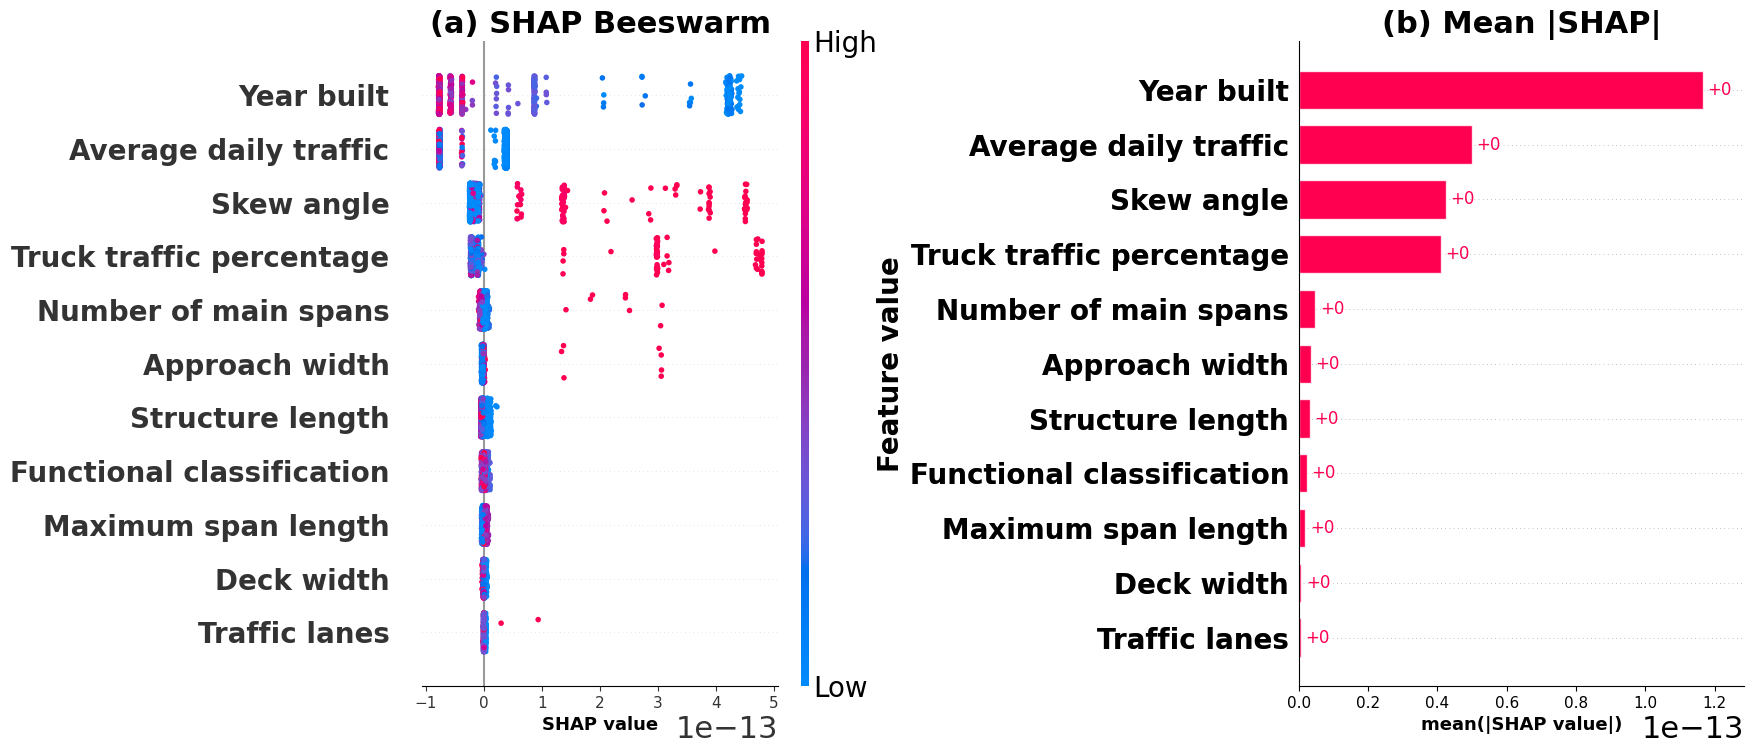

Saved:
chapter4_outputs/SHAP_stage1_summary_1x2.pdf
chapter4_outputs/SHAP_stage1_summary_1x2.png


In [13]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ============================================================
# SHAP SUMMARY PLOTS: 1×2 GRID
# CatBoost Stage One Model: FORM_FAMILY
# ============================================================

os.makedirs("chapter4_outputs", exist_ok=True)

# ===================== GLOBAL PLOT SETTINGS =====================
plt.rcParams.update({
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})

# ------------------------------------------------------------
# 1) SHAP explainer for final CatBoost model
# ------------------------------------------------------------
# X_shap should already be defined, for example:
# X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

print("Type of shap_values:", type(shap_values))
print("SHAP shape:", np.array(shap_values).shape)
print("X_shap shape:", X_shap.shape)
print("Model classes:", final_model.classes_)

# ------------------------------------------------------------
# 2) Convert multi-class SHAP values into one aggregated explanation
# ------------------------------------------------------------
shap_array = np.array(shap_values)

if isinstance(shap_values, list):
    # Older SHAP format:
    # list length = number of classes
    # each item = n_samples × n_features
    shap_stack = np.stack(shap_values, axis=2)

elif shap_array.ndim == 3:
    if shap_array.shape[1] == len(FEATURES):
        # Format: n_samples × n_features × n_classes
        shap_stack = shap_array
    elif shap_array.shape[2] == len(FEATURES):
        # Format: n_classes × n_samples × n_features
        shap_stack = np.transpose(shap_array, (1, 2, 0))
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

else:
    raise ValueError(f"Expected multi-class SHAP values, got shape: {shap_array.shape}")

# Aggregate signed SHAP values across classes
# This gives one SHAP matrix: n_samples × n_features
SHAP_vals = shap_stack.mean(axis=2)

# Aggregate base values across classes
if hasattr(explainer, "expected_value"):
    base_values = np.array(explainer.expected_value)

    if base_values.ndim == 1:
        base_value_agg = np.mean(base_values)
    else:
        base_value_agg = base_values
else:
    base_value_agg = 0

# ------------------------------------------------------------
# 3) Cleaner feature labels for thesis figures
# ------------------------------------------------------------
FEATURE_LABELS = {
    "STRUCTURE_LEN_MT_049": "Structure length",
    "MAX_SPAN_LEN_MT_048": "Maximum span length",
    "MAIN_UNIT_SPANS_045": "Number of main spans",
    "DECK_WIDTH_MT_052": "Deck width",
    "APPR_WIDTH_MT_032": "Approach width",
    "DEGREES_SKEW_034": "Skew angle",
    "ADT_029": "Average daily traffic",
    "PERCENT_ADT_TRUCK_109": "Truck traffic percentage",
    "TRAFFIC_LANES_ON_028A": "Traffic lanes",
    "YEAR_BUILT_027": "Year built",
    "FUNCTIONAL_CLASS_026": "Functional classification",
}

mapped_names = [FEATURE_LABELS.get(f, f) for f in FEATURES]

# ------------------------------------------------------------
# 4) Build aggregated SHAP Explanation object
# ------------------------------------------------------------
shap_values_agg = shap.Explanation(
    values=SHAP_vals,
    base_values=np.repeat(base_value_agg, X_shap.shape[0]),
    data=X_shap[FEATURES].values,
    feature_names=mapped_names
)

# ------------------------------------------------------------
# 5) Plot: 1×2 SHAP summary
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (a) SHAP Beeswarm
shap.plots.beeswarm(
    shap_values_agg,
    max_display=11,
    show=False,
    ax=axes[0],
    plot_size=None
)

axes[0].set_title("(a) SHAP Beeswarm", fontweight="bold")
axes[0].set_xlabel("SHAP value", fontweight="bold")

for label in axes[0].get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")

# Colorbar formatting
# SHAP adds the colorbar as the last axis
if len(fig.axes) > 2:
    cbar = fig.axes[-1]
    cbar.tick_params(labelsize=20)
    cbar.set_ylabel("Feature value", fontsize=20, fontweight="bold")

# (b) Mean |SHAP|
shap.plots.bar(
    shap_values_agg,
    max_display=11,
    show=False,
    ax=axes[1]
)

axes[1].set_title("(b) Mean |SHAP|", fontweight="bold")
axes[1].set_xlabel("mean(|SHAP value|)", fontweight="bold")

for label in axes[1].get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")

plt.tight_layout()

# ===================== EXPORT: 300 DPI PDF + PNG =====================
pdf_path = "chapter4_outputs/SHAP_stage1_summary_1x2.pdf"
png_path = "chapter4_outputs/SHAP_stage1_summary_1x2.png"

fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:")
print(pdf_path)
print(png_path)

Loaded model: chapter4_outputs/final_catboost_stage1_form_family_model.cbm
Model classes: ['arch' 'girder_beam' 'rigid_frame' 'truss']

Example input case:
                        Value
STRUCTURE_LEN_MT_049     45.0
MAX_SPAN_LEN_MT_048      18.0
MAIN_UNIT_SPANS_045       3.0
DECK_WIDTH_MT_052        10.5
APPR_WIDTH_MT_032         9.0
DEGREES_SKEW_034         10.0
ADT_029                3500.0
PERCENT_ADT_TRUCK_109     8.0
TRAFFIC_LANES_ON_028A     2.0
YEAR_BUILT_027         2025.0
FUNCTIONAL_CLASS_026      9.0

Predicted bridge form family: girder_beam

Prediction probabilities:
  Bridge form family  Predicted probability
1        girder_beam               0.998417
2        rigid_frame               0.000772
0               arch               0.000737
3              truss               0.000074


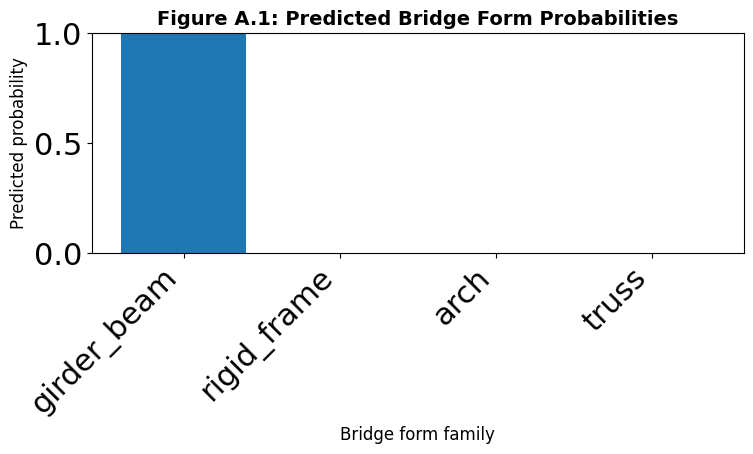


Local SHAP explanation for predicted class: girder_beam
                  Feature              Feature label  Input value  SHAP value  \
9          YEAR_BUILT_027          Design/build year       2025.0    0.639132   
2     MAIN_UNIT_SPANS_045       Number of main spans          3.0    0.393968   
0    STRUCTURE_LEN_MT_049       Structure length (m)         45.0    0.133618   
7   PERCENT_ADT_TRUCK_109          Truck traffic (%)          8.0    0.116413   
10   FUNCTIONAL_CLASS_026  Functional classification          9.0   -0.110925   
6                 ADT_029      Average daily traffic       3500.0   -0.093157   
3       DECK_WIDTH_MT_052             Deck width (m)         10.5    0.062054   
1     MAX_SPAN_LEN_MT_048    Maximum span length (m)         18.0   -0.057066   
4       APPR_WIDTH_MT_032         Approach width (m)          9.0   -0.037773   
5        DEGREES_SKEW_034       Skew angle (degrees)         10.0   -0.013044   
8   TRAFFIC_LANES_ON_028A              Traffic lanes

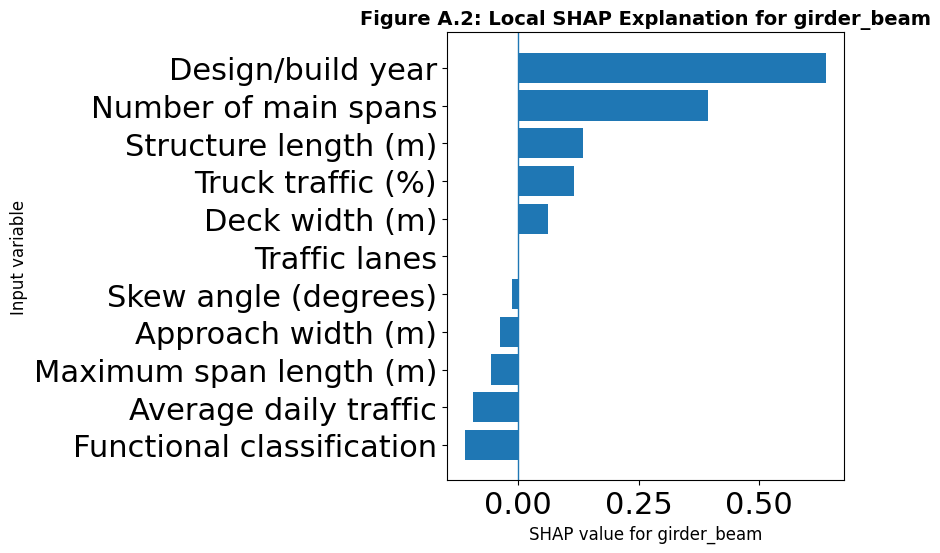

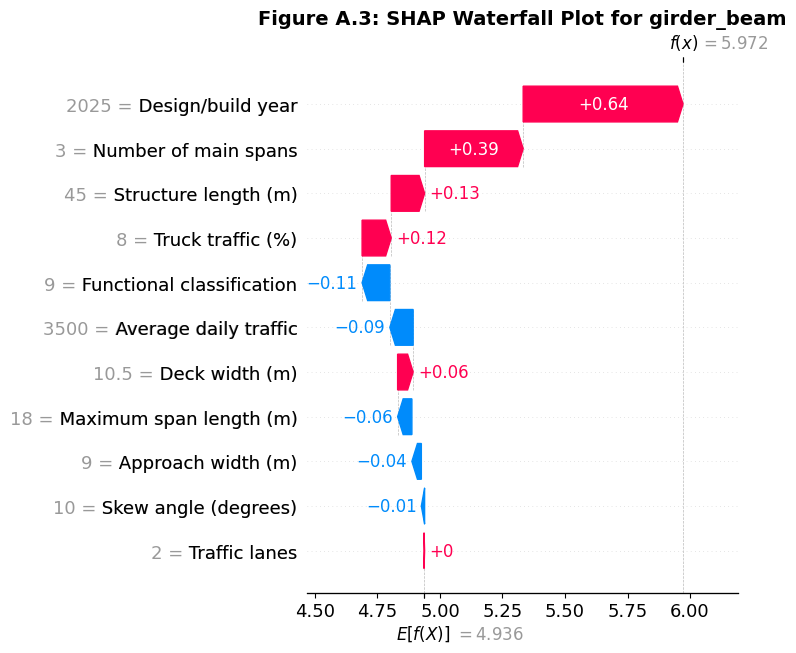


Top five variables influencing the prediction:
                Feature label  Input value  SHAP value
9           Design/build year       2025.0    0.639132
2        Number of main spans          3.0    0.393968
0        Structure length (m)         45.0    0.133618
7           Truck traffic (%)          8.0    0.116413
10  Functional classification          9.0   -0.110925

Saved appendix example outputs in: appendix_example_outputs/


In [14]:
# ============================================================
# Appendix A Example Application
# Preliminary Bridge Form Selection Using Final CatBoost Model
# Target: FORM_FAMILY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from catboost import CatBoostClassifier

# ------------------------------------------------------------
# 1) Output folder
# ------------------------------------------------------------
os.makedirs("appendix_example_outputs", exist_ok=True)

# ------------------------------------------------------------
# 2) Feature list used during model training
# ------------------------------------------------------------
FEATURES = [
    "STRUCTURE_LEN_MT_049",
    "MAX_SPAN_LEN_MT_048",
    "MAIN_UNIT_SPANS_045",
    "DECK_WIDTH_MT_052",
    "APPR_WIDTH_MT_032",
    "DEGREES_SKEW_034",
    "ADT_029",
    "PERCENT_ADT_TRUCK_109",
    "TRAFFIC_LANES_ON_028A",
    "YEAR_BUILT_027",
    "FUNCTIONAL_CLASS_026",
]

FEATURE_LABELS = {
    "STRUCTURE_LEN_MT_049": "Structure length (m)",
    "MAX_SPAN_LEN_MT_048": "Maximum span length (m)",
    "MAIN_UNIT_SPANS_045": "Number of main spans",
    "DECK_WIDTH_MT_052": "Deck width (m)",
    "APPR_WIDTH_MT_032": "Approach width (m)",
    "DEGREES_SKEW_034": "Skew angle (degrees)",
    "ADT_029": "Average daily traffic",
    "PERCENT_ADT_TRUCK_109": "Truck traffic (%)",
    "TRAFFIC_LANES_ON_028A": "Traffic lanes",
    "YEAR_BUILT_027": "Design/build year",
    "FUNCTIONAL_CLASS_026": "Functional classification",
}

# ------------------------------------------------------------
# 3) Load final trained CatBoost model
# ------------------------------------------------------------
# Change this path if your model is saved elsewhere.
model_path = "chapter4_outputs/final_catboost_stage1_form_family_model.cbm"

final_model = CatBoostClassifier()
final_model.load_model(model_path)

print("Loaded model:", model_path)
print("Model classes:", final_model.classes_)

# ------------------------------------------------------------
# 4) Define hypothetical preliminary bridge case
# ------------------------------------------------------------
# You can edit these values for your appendix example.

example_case = pd.DataFrame([{
    "STRUCTURE_LEN_MT_049": 45.0,       # total bridge length, m
    "MAX_SPAN_LEN_MT_048": 18.0,        # maximum span length, m
    "MAIN_UNIT_SPANS_045": 3,           # number of spans
    "DECK_WIDTH_MT_052": 10.5,          # deck width, m
    "APPR_WIDTH_MT_032": 9.0,           # approach width, m
    "DEGREES_SKEW_034": 10.0,           # skew angle, degrees
    "ADT_029": 3500,                    # average daily traffic
    "PERCENT_ADT_TRUCK_109": 8.0,       # truck traffic percentage
    "TRAFFIC_LANES_ON_028A": 2,         # traffic lanes
    "YEAR_BUILT_027": 2025,             # design/build year
    "FUNCTIONAL_CLASS_026": 9,          # functional classification
}])

example_case = example_case[FEATURES]

print("\nExample input case:")
print(example_case.T.rename(columns={0: "Value"}))

example_case.T.rename(columns={0: "Value"}).to_csv(
    "appendix_example_outputs/example_input_case.csv"
)

# ------------------------------------------------------------
# 5) Predict bridge form family
# ------------------------------------------------------------
pred_class = final_model.predict(example_case).reshape(-1)[0]
pred_proba = final_model.predict_proba(example_case)[0]

proba_df = pd.DataFrame({
    "Bridge form family": final_model.classes_,
    "Predicted probability": pred_proba
}).sort_values("Predicted probability", ascending=False)

print("\nPredicted bridge form family:", pred_class)
print("\nPrediction probabilities:")
print(proba_df)

proba_df.to_csv(
    "appendix_example_outputs/example_prediction_probabilities.csv",
    index=False
)

# ------------------------------------------------------------
# 6) Figure A.1: Prediction probability bar chart
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(proba_df["Bridge form family"], proba_df["Predicted probability"])
plt.title("Figure A.1: Predicted Bridge Form Probabilities", fontsize=14, fontweight="bold")
plt.xlabel("Bridge form family", fontsize=12)
plt.ylabel("Predicted probability", fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    "appendix_example_outputs/figure_A1_prediction_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 7) SHAP local explanation for the example case
# ------------------------------------------------------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(example_case)

# Convert SHAP values to a consistent class-specific format
shap_array = np.array(shap_values)

if isinstance(shap_values, list):
    # Older SHAP format: list of arrays, one per class
    # each array shape: n_samples x n_features
    shap_by_class = {
        class_name: shap_values[i][0]
        for i, class_name in enumerate(final_model.classes_)
    }

elif shap_array.ndim == 3:
    # Common CatBoost multi-class format
    # shape may be n_samples x n_features x n_classes
    if shap_array.shape[1] == len(FEATURES):
        shap_by_class = {
            class_name: shap_array[0, :, i]
            for i, class_name in enumerate(final_model.classes_)
        }

    # Alternative format: n_classes x n_samples x n_features
    elif shap_array.shape[2] == len(FEATURES):
        shap_by_class = {
            class_name: shap_array[i, 0, :]
            for i, class_name in enumerate(final_model.classes_)
        }

    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

else:
    raise ValueError(f"Unexpected SHAP format: {shap_array.shape}")

# Select predicted class explanation
pred_class_shap = shap_by_class[pred_class]

local_shap_df = pd.DataFrame({
    "Feature": FEATURES,
    "Feature label": [FEATURE_LABELS.get(f, f) for f in FEATURES],
    "Input value": example_case.iloc[0].values,
    "SHAP value": pred_class_shap
})

local_shap_df["Absolute SHAP"] = local_shap_df["SHAP value"].abs()
local_shap_df = local_shap_df.sort_values("Absolute SHAP", ascending=False)

print(f"\nLocal SHAP explanation for predicted class: {pred_class}")
print(local_shap_df)

local_shap_df.to_csv(
    "appendix_example_outputs/example_local_shap_explanation.csv",
    index=False
)

# ------------------------------------------------------------
# 8) Figure A.2: Local SHAP contribution bar chart
# ------------------------------------------------------------
plot_df = local_shap_df.sort_values("SHAP value")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["Feature label"], plot_df["SHAP value"])
plt.axvline(0, linewidth=1)
plt.title(
    f"Figure A.2: Local SHAP Explanation for {pred_class}",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(f"SHAP value for {pred_class}", fontsize=12)
plt.ylabel("Input variable", fontsize=12)
plt.tight_layout()
plt.savefig(
    "appendix_example_outputs/figure_A2_local_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 9) Optional: SHAP waterfall plot for predicted class
# ------------------------------------------------------------
# This requires a class-specific base value.

expected_value = explainer.expected_value

if isinstance(expected_value, list) or isinstance(expected_value, np.ndarray):
    class_index = list(final_model.classes_).index(pred_class)
    base_value = expected_value[class_index]
else:
    base_value = expected_value

shap_exp = shap.Explanation(
    values=pred_class_shap,
    base_values=base_value,
    data=example_case.iloc[0].values,
    feature_names=[FEATURE_LABELS.get(f, f) for f in FEATURES]
)

plt.figure(figsize=(9, 7))
shap.plots.waterfall(shap_exp, max_display=11, show=False)
plt.title(
    f"Figure A.3: SHAP Waterfall Plot for {pred_class}",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    "appendix_example_outputs/figure_A3_shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 10) Simple text summary for appendix
# ------------------------------------------------------------
top_features = local_shap_df.head(5)[
    ["Feature label", "Input value", "SHAP value"]
]

print("\nTop five variables influencing the prediction:")
print(top_features)

summary_text = f"""
Example preliminary bridge case prediction

Predicted bridge form family: {pred_class}

Prediction probabilities:
{proba_df.to_string(index=False)}

Top five SHAP contributors for the predicted class:
{top_features.to_string(index=False)}
"""

with open("appendix_example_outputs/example_prediction_summary.txt", "w") as f:
    f.write(summary_text)

print("\nSaved appendix example outputs in: appendix_example_outputs/")